# 20231329 자율이동체 중간과제  


In [1]:
# 공통 설정 및 라이브러리
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    import cv2
    CV2_AVAILABLE = True
except Exception as e:
    CV2_AVAILABLE = False
    print("OpenCV(cv2)를 불러오지 못했습니다.")
    print(e)

# 과제에서 사용할 sequence 번호
SEQUENCE = "09"

# image_0을 사용하면 CAMERA_ID = 0, image_1을 사용하면 CAMERA_ID = 1
CAMERA_ID = 0

# KITTI odometry는 일반적으로 10 FPS로 사용
FPS = 10.0

# 현재 PC에 저장된 KITTI 데이터 경로
GRAY_DATASET_DIR = Path(r"C:\Users\김수연\Desktop\data_odometry_gray\dataset")
POSE_DATASET_DIR = Path(r"C:\Users\김수연\Desktop\data_odometry_poses\dataset")

# gray sequence 09에서 사용할 파일 경로
SEQ_DIR = GRAY_DATASET_DIR / "sequences" / SEQUENCE
IMG_DIR = SEQ_DIR / f"image_{CAMERA_ID}"
CALIB_PATH = SEQ_DIR / "calib.txt"
TIMES_PATH = SEQ_DIR / "times.txt"

# pose 파일 경로
POSE_PATH = POSE_DATASET_DIR / "poses" / f"{SEQUENCE}.txt"

print("SEQUENCE:", SEQUENCE)
print("CAMERA_ID:", CAMERA_ID)

print("\n[gray image data]")
print("SEQ_DIR:", SEQ_DIR)
print("IMG_DIR:", IMG_DIR)
print("CALIB_PATH:", CALIB_PATH)
print("TIMES_PATH:", TIMES_PATH)

print("\n[pose data]")
print("POSE_PATH:", POSE_PATH)

print("\n[경로 존재 여부 확인]")
print("GRAY_DATASET_DIR 존재:", GRAY_DATASET_DIR.exists())
print("POSE_DATASET_DIR 존재:", POSE_DATASET_DIR.exists())
print("SEQ_DIR 존재:", SEQ_DIR.exists())
print("IMG_DIR 존재:", IMG_DIR.exists())
print("CALIB_PATH 존재:", CALIB_PATH.exists())
print("TIMES_PATH 존재:", TIMES_PATH.exists())
print("POSE_PATH 존재:", POSE_PATH.exists())

if IMG_DIR.exists():
    png_count = len(list(IMG_DIR.glob("*.png")))
    print("image_0 png 개수:", png_count)
else:
    print("image_0 png 개수: IMG_DIR이 존재하지 않아 확인할 수 없습니다.")

SEQUENCE: 09
CAMERA_ID: 0

[gray image data]
SEQ_DIR: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09
IMG_DIR: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\image_0
CALIB_PATH: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\calib.txt
TIMES_PATH: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\times.txt

[pose data]
POSE_PATH: C:\Users\김수연\Desktop\data_odometry_poses\dataset\poses\09.txt

[경로 존재 여부 확인]
GRAY_DATASET_DIR 존재: True
POSE_DATASET_DIR 존재: True
SEQ_DIR 존재: True
IMG_DIR 존재: True
CALIB_PATH 존재: True
TIMES_PATH 존재: True
POSE_PATH 존재: True
image_0 png 개수: 1591


---

## 문제 1. Projection Matrix 해석

Projection Matrix는 **world 좌표계에 있는 3D 점을 카메라 이미지 위의 2D 픽셀 좌표로 변환하는 행렬**이다.  
즉, 실제 공간에 있는 한 점 $(X_w,Y_w,Z_w)$가 카메라 이미지에서 어느 픽셀 위치 $(u,v)$에 보이는지를 계산한다.

OpenCV의 pinhole camera model에서는 이 변환을 다음과 같이 표현한다.

$$
s\begin{bmatrix}
u\\
v\\
1
\end{bmatrix}
=
\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x\\
r_{21} & r_{22} & r_{23} & t_y\\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
\begin{bmatrix}
X_w\\
Y_w\\
Z_w\\
1
\end{bmatrix}
$$

위 식은 간단히 다음과 같이 쓸 수 있다.

$$
s p = K[R|t]P_w
$$

여기서 각각의 의미는 다음과 같다.

- $P_w=[X_w,Y_w,Z_w,1]^T$: world 좌표계에서 표현한 3D 점이다. 실제 공간에 있는 점의 위치를 나타낸다.
- $p=[u,v,1]^T$: 이미지 평면 위의 2D 픽셀 좌표 $(u,v)$를 동차좌표 형태로 표현한 것이다. 여기서 $u$는 이미지의 가로 방향 픽셀 좌표이고, $v$는 이미지의 세로 방향 픽셀 좌표이다.
- $s$: 동차좌표에서 사용하는 scale factor이다. 행렬 계산 결과를 실제 픽셀 좌표 $(u,v)$로 바꾸기 위해 마지막 성분으로 나누는 데 사용된다.
- $K$: intrinsic matrix이다. 카메라 내부 파라미터를 담고 있다.
- $[R|t]$: extrinsic matrix이다. 카메라의 외부 위치와 방향 정보를 담고 있다.

여기서 **동차좌표 homogeneous coordinate**란 원래 좌표에 1을 하나 추가하여 행렬 곱셈으로 좌표 변환을 표현하기 쉽게 만든 좌표이다. 예를 들어 이미지 위의 2D 점 $(u,v)$는 원래 두 개의 값만 가지지만, 행렬식에서는 다음처럼 표현한다.

$$
p=
\begin{bmatrix}
u\\
v\\
1
\end{bmatrix}
$$

Projection matrix를 곱한 결과는 바로 $[u,v,1]^T$가 아니라 보통 다음과 같은 형태로 계산된다.

$$
\begin{bmatrix}
su\\
sv\\
s
\end{bmatrix}
$$

따라서 실제 이미지 좌표를 얻기 위해서는 마지막 성분 $s$로 나누어야 한다.

$$
u=\frac{su}{s}, \quad v=\frac{sv}{s}
$$

즉, $s$는 최종 픽셀 좌표 $(u,v)$를 얻기 위해 나누어주는 scale 값이다.

---

### 1). Intrinsic parameter의 의미

Intrinsic parameter는 **카메라 내부 파라미터**이다.  
즉, 카메라 자체가 가지고 있는 초점거리와 이미지 중심점 정보를 나타낸다.

$$
K =
\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
$$

- $f_x$: 이미지 좌표계의 x축 방향 focal length이며, 단위는 pixel이다.
- $f_y$: 이미지 좌표계의 y축 방향 focal length이며, 단위는 pixel이다.
- $c_x$: principal point의 x좌표이다. 
- $c_y$: principal point의 y좌표이다. 

즉, intrinsic parameter는 **카메라 좌표계의 3D 점을 이미지 평면의 픽셀 좌표로 바꾸는 역할**을 한다.

---

### 2). Extrinsic parameter의 역할

Extrinsic parameter는 **카메라 외부 파라미터**이다.  
즉, 카메라가 world 좌표계에서 어디에 있고, 어떤 방향을 바라보고 있는지를 나타낸다.

$$
[R|t]
=
\begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x\\
r_{21} & r_{22} & r_{23} & t_y\\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
$$

여기서 $R$은 3×3 rotation matrix이고, $t$는 3×1 translation vector이다.

$$
R=
\begin{bmatrix}
r_{11} & r_{12} & r_{13}\\
r_{21} & r_{22} & r_{23}\\
r_{31} & r_{32} & r_{33}
\end{bmatrix},
\quad
 t=
\begin{bmatrix}
t_x\\
t_y\\
t_z
\end{bmatrix}
$$

따라서 extrinsic parameter는 world 좌표계의 3D 점을 camera 좌표계의 3D 점으로 변환한다.

$$
\begin{bmatrix}
X_c\\
Y_c\\
Z_c
\end{bmatrix}
=
\begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x\\
r_{21} & r_{22} & r_{23} & t_y\\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
\begin{bmatrix}
X_w\\
Y_w\\
Z_w\\
1
\end{bmatrix}
$$

이를 성분별로 풀어 쓰면 다음과 같다.

$$
X_c = r_{11}X_w + r_{12}Y_w + r_{13}Z_w + t_x
$$

$$
Y_c = r_{21}X_w + r_{22}Y_w + r_{23}Z_w + t_y
$$

$$
Z_c = r_{31}X_w + r_{32}Y_w + r_{33}Z_w + t_z
$$

즉, $[R|t]$는 실제 world 좌표의 점 $(X_w,Y_w,Z_w)$를 카메라 기준의 점 $(X_c,Y_c,Z_c)$로 바꾼다.

---

### 3). 전체 Projection Matrix를 하나의 행렬로 쓰기

전체 projection matrix $P$는 intrinsic matrix $K$와 extrinsic matrix $[R|t]$를 곱한 것이다.

$$
P = K[R|t]
$$

이를 직접 곱하면 다음과 같은 3×4 행렬이 된다.

$$
P =
\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x\\
r_{21} & r_{22} & r_{23} & t_y\\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
$$

$$
P =
\begin{bmatrix}
f_xr_{11}+c_xr_{31} & f_xr_{12}+c_xr_{32} & f_xr_{13}+c_xr_{33} & f_xt_x+c_xt_z\\
f_yr_{21}+c_yr_{31} & f_yr_{22}+c_yr_{32} & f_yr_{23}+c_yr_{33} & f_yt_y+c_yt_z\\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
$$

따라서 3D 점을 이미지 좌표로 변환하는 전체 식은 다음과 같이 쓸 수 있다.

$$
s
\begin{bmatrix}
u\\
v\\
1
\end{bmatrix}
=
P
\begin{bmatrix}
X_w\\
Y_w\\
Z_w\\
1
\end{bmatrix}
$$

---

### 4). 이 행렬이 3D 점을 이미지 좌표로 변환하는 과정

먼저 world 좌표계의 3D 점을 extrinsic matrix로 camera 좌표계의 점으로 바꾼다.

$$
\begin{bmatrix}
X_c\\
Y_c\\
Z_c
\end{bmatrix}
=
[R|t]
\begin{bmatrix}
X_w\\
Y_w\\
Z_w\\
1
\end{bmatrix}
$$

그 다음 intrinsic matrix를 적용하면 다음과 같다.

$$
s
\begin{bmatrix}
u\\
v\\
1
\end{bmatrix}
=
\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
X_c\\
Y_c\\
Z_c
\end{bmatrix}
$$

오른쪽을 직접 계산하면 다음과 같다.

$$
s
\begin{bmatrix}
u\\
v\\
1
\end{bmatrix}
=
\begin{bmatrix}
f_xX_c+c_xZ_c\\
f_yY_c+c_yZ_c\\
Z_c
\end{bmatrix}
$$

동차좌표에서는 계산 결과의 마지막 성분으로 나누어 실제 이미지 좌표를 얻는다. 따라서 다음과 같이 정리할 수 있다.

$$
u = \frac{f_xX_c+c_xZ_c}{Z_c}
= f_x\frac{X_c}{Z_c}+c_x
$$

$$
v = \frac{f_yY_c+c_yZ_c}{Z_c}
= f_y\frac{Y_c}{Z_c}+c_y
$$

즉, 최종적으로 3D 점 $(X_w,Y_w,Z_w)$는 이미지 위의 2D 픽셀 좌표 $(u,v)$로 변환된다.


---

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

문제 2번에서는 **임의의 3D 점들을 생성한 뒤**, projection matrix $P$를 이용해 sequence 09의 이미지 위 2D 좌표로 투영한다.

3D 점을 $[X,Y,Z]^T$라고 하면, 행렬 곱을 위해 먼저 동차좌표로 바꾸어 다음과 같이 표현한다.

$$
X_h = [X,Y,Z,1]^T
$$

그 다음 projection matrix를 곱한다.

$$
q = PX_h = [q_x,q_y,q_z]^T
$$

이 결과는 아직 최종 픽셀 좌표가 아니므로, 마지막 성분 $q_z$로 나누어 이미지 좌표를 얻는다.

$$
u=\frac{q_x}{q_z}, \quad v=\frac{q_y}{q_z}
$$

이렇게 계산한 $(u,v)$를 sequence 09의 `image_0` 위에 점으로 표시한다.


사용한 calibration file: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\calib.txt
사용한 projection matrix key: P0
Projection matrix P shape: (3, 4)
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

P의 왼쪽 3x3 부분:
[[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]

fx=707.091, fy=707.091, cx=601.887, cy=183.110

frame count: 1591
first frame: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\image_0\000000.png
image shape: (370, 1226)

생성한 3D 점 개수: 495
이미지 안에 투영된 점 개수: 460


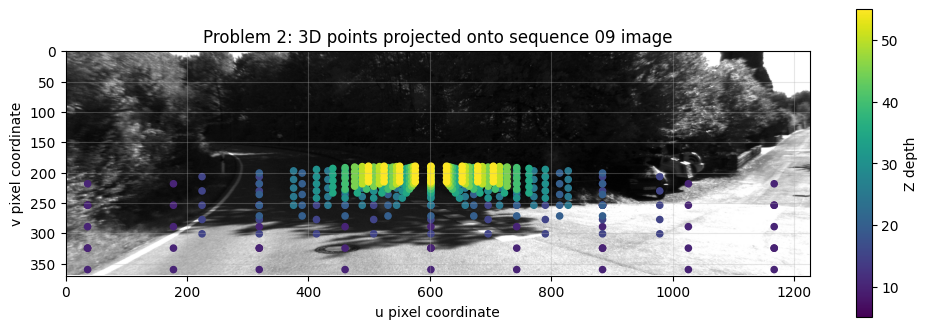

투영된 점 일부:
3D point [-4.   0.5  5. ] -> image coordinate (u, v)=(36.2, 253.8), depth=5.0
3D point [-2.   0.5  5. ] -> image coordinate (u, v)=(319.1, 253.8), depth=5.0
3D point [0.  0.5 5. ] -> image coordinate (u, v)=(601.9, 253.8), depth=5.0
3D point [2.  0.5 5. ] -> image coordinate (u, v)=(884.7, 253.8), depth=5.0
3D point [4.  0.5 5. ] -> image coordinate (u, v)=(1167.6, 253.8), depth=5.0
3D point [-4.  1.  5.] -> image coordinate (u, v)=(36.2, 324.5), depth=5.0
3D point [-2.  1.  5.] -> image coordinate (u, v)=(319.1, 324.5), depth=5.0
3D point [0. 1. 5.] -> image coordinate (u, v)=(601.9, 324.5), depth=5.0
3D point [2. 1. 5.] -> image coordinate (u, v)=(884.7, 324.5), depth=5.0
3D point [4. 1. 5.] -> image coordinate (u, v)=(1167.6, 324.5), depth=5.0


In [2]:
# 문제 2. Projection Matrix를 이용한 3D -> 2D 투영


# 1) sequence 09의 calibration file에서 projection matrix P 읽기

def read_kitti_calib(calib_path: Path) -> dict:
    """
    KITTI calib.txt에서 P0, P1, P2, P3 같은 3x4 projection matrix를 읽는다.

    각 P 행렬은 숫자 12개로 저장되어 있으므로,
    이를 3x4 행렬로 바꾸어 저장한다.
    """
    if not calib_path.exists():
        raise FileNotFoundError(
            f"calib.txt를 찾을 수 없습니다: {calib_path}\n"
            "C:\\Users\\김수연\\Desktop\\data_odometry_gray\\dataset\\sequences\\09 안에 calib.txt가 있는지 확인하세요."
        )

    calib = {}

    with open(calib_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # 빈 줄이거나 ':'가 없는 줄은 calibration 행렬이 아니므로 건너뛴다.
            if not line or ":" not in line:
                continue

            key, values = line.split(":", 1)
            nums = np.array([float(x) for x in values.split()], dtype=np.float64)

            # P0, P1, P2, P3는 숫자 12개로 이루어진 3x4 projection matrix이다.
            if nums.size == 12:
                calib[key] = nums.reshape(3, 4)

    return calib


calib = read_kitti_calib(CALIB_PATH)

# image_0을 사용하면 P0를 사용한다.
# image_1을 사용하려면 CAMERA_ID=1로 바꾸고 P1을 사용하면 된다.
P_KEY = f"P{CAMERA_ID}"

if P_KEY not in calib:
    raise KeyError(
        f"{P_KEY}를 calib.txt에서 찾을 수 없습니다. "
        f"현재 calib.txt에 있는 projection matrix key: {list(calib.keys())}"
    )

P = calib[P_KEY]

print("사용한 calibration file:", CALIB_PATH)
print("사용한 projection matrix key:", P_KEY)
print("Projection matrix P shape:", P.shape)
print(P)

# P의 왼쪽 3x3 부분은 intrinsic matrix K와 같은 형태를 가진다.
# 여기서 fx, fy, cx, cy 값을 확인할 수 있다.
K_approx = P[:, :3]
fx = K_approx[0, 0]
fy = K_approx[1, 1]
cx = K_approx[0, 2]
cy = K_approx[1, 2]

print("\nP의 왼쪽 3x3 부분:")
print(K_approx)
print(f"\nfx={fx:.3f}, fy={fy:.3f}, cx={cx:.3f}, cy={cy:.3f}")


# 2) sequence 09의 image_0 프레임 읽기

def list_frames(img_dir: Path):
    """
    gray sequence 09의 image_0 폴더에서 png 이미지 목록을 가져온다.

    문제에서 sequence 09를 사용해야 하므로,
    이미지가 없을 때 blank image를 만들지 않고 오류를 발생시킨다.
    """
    if not img_dir.exists():
        raise FileNotFoundError(
            f"sequence 09 이미지 폴더를 찾을 수 없습니다: {img_dir}\n"
            "C:\\Users\\김수연\\Desktop\\data_odometry_gray\\dataset\\sequences\\09\\image_0 경로를 확인하세요."
        )

    frames = sorted(img_dir.glob("*.png"))

    if len(frames) == 0:
        raise FileNotFoundError(
            f"sequence 09 이미지 폴더 안에 png 이미지가 없습니다: {img_dir}\n"
            "image_0 폴더 안에 KITTI 이미지 파일이 있는지 확인하세요."
        )

    return frames


frames = list_frames(IMG_DIR)
print("\nframe count:", len(frames))
print("first frame:", frames[0])

# 첫 번째 프레임을 grayscale 이미지로 읽는다.
sample_img = np.array(Image.open(frames[0]).convert("L"), dtype=np.uint8)

H, W = sample_img.shape
print("image shape:", sample_img.shape)


# 3) 3D 점을 2D 이미지 좌표로 투영하는 함수

def project_points(P: np.ndarray, points_xyz: np.ndarray):
    """
    3D 점들을 projection matrix P로 이미지 좌표에 투영한다.

    입력:
        P: 3x4 projection matrix
        points_xyz: (N, 3) 형태의 3D 점 배열
                    각 점은 [X, Y, Z]로 표현된다.

    출력:
        uv: (N, 2) 형태의 이미지 좌표 배열
            각 점은 [u, v]로 표현된다.
        depth: 투영 결과의 세 번째 값 q_z
               depth > 0이면 카메라 앞쪽에 있는 점으로 볼 수 있다.
    """

    # 3D 점 [X, Y, Z]에 1을 붙여 [X, Y, Z, 1] 형태의 동차좌표로 만든다.
    points_h = np.hstack([
        points_xyz,
        np.ones((len(points_xyz), 1))
    ])

    # projection matrix를 곱한다.
    # q는 [q_x, q_y, q_z] 형태의 중간 결과이다.
    q = (P @ points_h.T).T

    # q_x, q_y를 q_z로 나누면 최종 이미지 좌표 (u, v)가 된다.
    uv = q[:, :2] / q[:, 2:3]

    # q_z는 점이 카메라 앞쪽에 있는지 확인할 때 사용한다.
    depth = q[:, 2]

    return uv, depth


# 4) 카메라 앞쪽에 임의의 3D 점 생성
# 이번 버전에서는 Y를 고정하지 않고 X, Y, Z를 모두 변화시킨다.
#
# KITTI/OpenCV 카메라 좌표계에서는 보통 다음처럼 해석한다.
# X: 오른쪽 방향
# Y: 아래쪽 방향
# Z: 카메라 전방 방향
#
# 따라서 X를 바꾸면 이미지에서 좌우 위치가 달라지고,
# Y를 바꾸면 이미지에서 위아래 위치가 달라지며,
# Z를 바꾸면 카메라로부터의 거리가 달라진다.

xs = np.linspace(-8, 8, 9)       # 좌우 방향 위치
ys = np.linspace(0.5, 2.5, 5)    # 위아래 방향 위치
zs = np.linspace(5, 55, 11)      # 카메라 앞쪽 거리

points = []

for z in zs:
    for y in ys:
        for x in xs:
            points.append([x, y, z])

points = np.array(points, dtype=np.float64)

print("\n생성한 3D 점 개수:", len(points))


# 5) projection matrix를 이용해 3D 점을 이미지 좌표로 투영

uv, depth = project_points(P, points)

# 이미지 안에 들어오고, 카메라 앞쪽에 있는 점만 선택한다.
valid = (
    (depth > 0) &
    (uv[:, 0] >= 0) & (uv[:, 0] < W) &
    (uv[:, 1] >= 0) & (uv[:, 1] < H)
)

print("이미지 안에 투영된 점 개수:", int(np.sum(valid)))


# 6) 투영된 점들을 sequence 09 이미지 위에 시각화

plt.figure(figsize=(12, 4))
plt.imshow(sample_img, cmap="gray")

# 점의 색은 Z값, 즉 카메라와의 거리를 나타낸다.
# 색이 다르면 서로 다른 깊이의 3D 점들이 이미지에 어떻게 투영되는지 확인할 수 있다.
scatter = plt.scatter(
    uv[valid, 0],
    uv[valid, 1],
    c=points[valid, 2],
    s=20
)

plt.colorbar(scatter, label="Z depth")
plt.title("Problem 2: 3D points projected onto sequence 09 image")
plt.xlabel("u pixel coordinate")
plt.ylabel("v pixel coordinate")

# 이미지 좌표계는 왼쪽 위가 원점이므로 y축을 아래 방향으로 표시한다.
plt.xlim(0, W)
plt.ylim(H, 0)

plt.grid(alpha=0.3)
plt.show()


# 투영 결과 일부를 숫자로 확인한다.
print("투영된 점 일부:")
for i in np.where(valid)[0][:10]:
    print(
        f"3D point {points[i]} -> "
        f"image coordinate (u, v)=({uv[i, 0]:.1f}, {uv[i, 1]:.1f}), "
        f"depth={depth[i]:.1f}"
    )

### 문제 2 결과 해석

문제 2에서는 임의의 3D 점들을 생성한 뒤, projection matrix를 이용하여 2D 이미지 좌표로 투영하였다. 현재 실험에서는 sequence 09의 `image_0` 이미지를 사용했기 때문에, `calib.txt`에서 `P0` projection matrix를 읽어 사용하였다.

생성한 3D 점은 다음과 같이 표현된다.

$$
[X, Y, Z]
$$

여기서 `X`는 좌우 방향, `Y`는 위아래 방향, `Z`는 카메라 전방 방향의 깊이를 의미한다. 코드에서는 `X`, `Y`, `Z` 값을 모두 변화시켜 총 495개의 3D 점을 만들었고, 그중 460개의 점이 이미지 범위 안에 투영되었다.

3D 점을 projection matrix로 투영하기 위해 먼저 동차좌표 형태로 바꾸었다.

$$
[X, Y, Z]
\rightarrow
[X, Y, Z, 1]^T
$$

그다음 projection matrix `P`를 곱해 다음과 같은 중간 결과를 얻었다.

$$
\begin{bmatrix}
q_x \\
q_y \\
q_z
\end{bmatrix}
=
P
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}
$$

이 결과는 아직 최종 이미지 좌표가 아니다. 최종 이미지 좌표는 첫 번째 성분과 두 번째 성분을 세 번째 성분으로 나누어 계산한다.

$$
u = \frac{q_x}{q_z}
$$

$$
v = \frac{q_y}{q_z}
$$

따라서 각 3D 점은 이미지 위의 2D 픽셀 좌표로 변환된다.

$$
[X, Y, Z]
\rightarrow
(u, v)
$$

시각화 결과에서 이미지 위에 표시된 점들은 임의로 생성한 3D 점들이 projection matrix를 통해 이미지 평면 위에 투영된 위치이다.

오른쪽의 colorbar는 `Z depth`를 나타낸다. 즉, 점의 색은 해당 3D 점이 카메라로부터 얼마나 멀리 있는지를 의미한다. 보라색 계열에 가까운 점은 `Z` 값이 작은 점으로, 카메라에 가까운 점이다. 노란색 계열에 가까운 점은 `Z` 값이 큰 점으로, 카메라에서 먼 점이다.

결과를 보면 `X` 값이 달라질수록 점의 가로 위치가 변한다. 즉, 3D 공간에서 왼쪽 또는 오른쪽에 있는 점은 이미지에서도 왼쪽 또는 오른쪽 위치에 투영된다.

또한 `Y` 값이 달라질수록 점의 세로 위치가 변한다. 코드에서는 `Y` 값도 여러 개로 변화시켰기 때문에, 이미지 위의 점들이 세로 방향으로도 여러 줄처럼 나타난다.

마지막으로 `Z` 값이 커질수록, 즉 카메라에서 멀리 있는 점일수록 이미지에서 중심 방향으로 모이는 경향을 보인다. 이는 카메라의 원근 투영식과 일치한다.

$$
u = f_x \frac{X}{Z} + c_x
$$

$$
v = f_y \frac{Y}{Z} + c_y
$$


위 식에서 $Z$가 커지면 $\dfrac{X}{Z}$와 $\dfrac{Y}{Z}$ 값이 작아진다. 따라서 멀리 있는 점일수록 이미지 좌표는 principal point인 $(c_x, c_y)$ 근처로 가까워진다. 반대로 $Z$가 작은 가까운 점들은 $\dfrac{X}{Z}$, $\dfrac{Y}{Z}$ 값이 상대적으로 크기 때문에 이미지에서 더 넓게 퍼져 보인다.

즉, 결과는 3D 공간의 점들이 projection matrix를 통해 2D 이미지 좌표로 변환되는 과정을 보여준다. 또한 가까운 점은 이미지에서 넓게 퍼지고, 먼 점은 중심 방향으로 모이는 형태를 보이므로, 카메라의 원근 투영 특성과 일치한다.

---

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 파일의 각 행은 12개의 숫자로 되어 있고, 이를 3×4 행렬로 reshape하면 $[R|t]$ 형태가 됩니다.  
여기서 오른쪽 3×1 열 $t$는 초기 프레임 좌표계를 기준으로 한 카메라 위치로 해석할 수 있습니다.


pose file loaded: C:\Users\김수연\Desktop\data_odometry_poses\dataset\poses\09.txt
pose shape: (1591, 3, 4)
first 5 positions [x, y, z]:
          x         y         z
0  0.000000  0.000000  0.000000
1  0.021389 -0.008456  0.288071
2  0.038790 -0.015138  0.580734
3  0.054181 -0.020081  0.879235
4  0.065151 -0.024741  1.185210


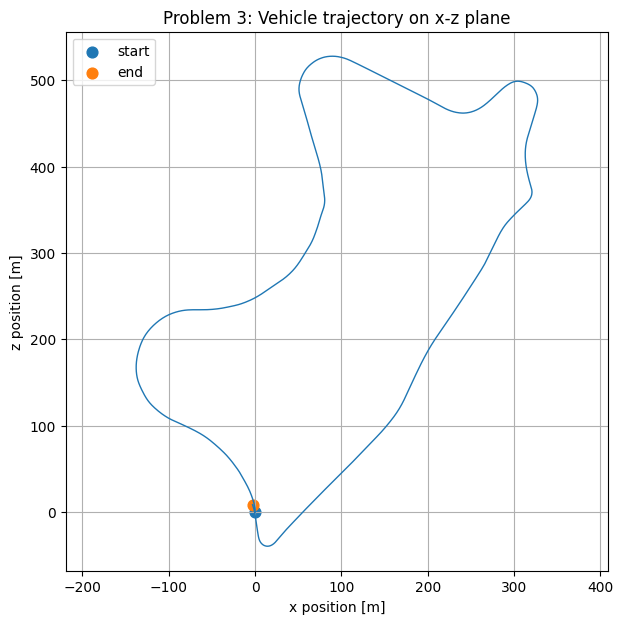

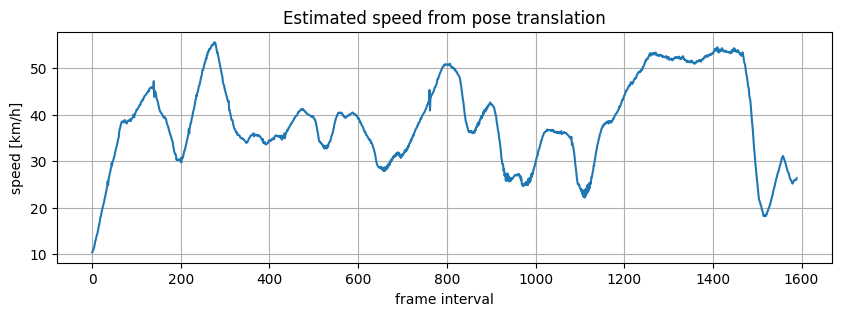

평균 속도: 38.60 km/h
최대 속도: 55.62 km/h
최소 속도: 10.40 km/h


In [3]:
#문제 3. Pose를 이용한 차량 궤적 시각화
def load_poses_kitti(path: Path) -> np.ndarray:
    """
    KITTI pose txt를 (N, 3, 4) 배열로 읽는다.

    poses/09.txt의 각 줄은 숫자 12개로 되어 있고,
    이를 3x4 행렬로 바꾸면 각 프레임의 pose 행렬이 된다.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"pose 파일을 찾을 수 없습니다: {path}\n"
            "C:\\Users\\김수연\\Desktop\\data_odometry_poses\\dataset\\poses 안에 09.txt가 있는지 확인하세요."
        )

    data = pd.read_csv(path, sep=r"\s+", header=None).values.astype(np.float64)
    return data.reshape(-1, 3, 4)


gt = load_poses_kitti(POSE_PATH)
print("pose file loaded:", POSE_PATH)

positions = gt[:, :, 3].copy()
positions = positions - positions[0]  # 초기 프레임을 기준 좌표계로 설정

print("pose shape:", gt.shape)
print("first 5 positions [x, y, z]:")
print(pd.DataFrame(positions[:5], columns=["x", "y", "z"]))

#차량 이동 궤적을 x-z평면에 2D로 시각화
plt.figure(figsize=(7, 7))
plt.plot(positions[:, 0], positions[:, 2], linewidth=1)
plt.scatter(positions[0, 0], positions[0, 2], s=60, label="start")
plt.scatter(positions[-1, 0], positions[-1, 2], s=60, label="end")
plt.xlabel("x position [m]")
plt.ylabel("z position [m]")
plt.title("Problem 3: Vehicle trajectory on x-z plane")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# 프레임 간 이동 거리와 속도 계산
step_dist = np.linalg.norm(np.diff(positions, axis=0), axis=1)
speed_mps = step_dist * FPS
speed_kmh = speed_mps * 3.6

plt.figure(figsize=(10, 3))
plt.plot(speed_kmh)
plt.xlabel("frame interval")
plt.ylabel("speed [km/h]")
plt.title("Estimated speed from pose translation")
plt.grid(True)
plt.show()

print(f"평균 속도: {np.mean(speed_kmh):.2f} km/h")
print(f"최대 속도: {np.max(speed_kmh):.2f} km/h")
print(f"최소 속도: {np.min(speed_kmh):.2f} km/h")


### 문제 3 결과 해석

KITTI pose 데이터 `poses/09.txt`를 읽어 각 프레임의 pose 행렬을 불러왔다. 각 pose 행렬은 `[R | t]` 형태이며, 마지막 열 `t`는 해당 프레임에서의 카메라 또는 차량의 위치를 의미한다. 따라서 코드에서는 각 프레임의 translation vector를 추출하여 차량 위치 `[x, y, z]`로 사용하였다.

초기 프레임을 기준 좌표계로 설정하기 위해 첫 번째 프레임의 위치를 모든 위치에서 빼 주었다. 그 결과 시작 위치가 `(0, 0, 0)`이 되었고, 이후 위치들은 시작점을 기준으로 한 상대적인 이동 위치가 되었다.

차량의 이동 궤적은 x-z 평면에 2D로 시각화하였다. 그래프에서 `start`는 시작 위치, `end`는 마지막 위치를 의미하며, 파란 선은 sequence 09 동안 차량이 이동한 경로를 나타낸다. 이를 통해 차량이 직선으로만 이동한 것이 아니라, 여러 번 방향을 바꾸며 곡선 형태의 경로를 따라 이동했음을 확인할 수 있다.

속도는 인접한 두 프레임 사이의 이동 거리를 이용해 계산하였다. KITTI odometry 데이터를 10 FPS로 가정하여 프레임 간 이동 거리에 FPS를 곱해 m/s 단위 속도를 구하고, 여기에 3.6을 곱해 km/h 단위로 변환하였다.

실행 결과 평균 속도는 약 38.60 km/h, 최대 속도는 약 55.62 km/h, 최소 속도는 약 10.40 km/h로 나타났다. 속도 그래프를 보면 차량의 속도가 일정하지 않고 구간별로 증가와 감소를 반복하는 것을 확인할 수 있다. 이는 차량이 주행 중 직선 구간, 곡선 구간, 감속 구간 등을 지나며 속도가 변화했기 때문으로 해석할 수 있다.

---

## 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류로 도로 후보 영역을 얻은 뒤, 그 안에서 edge와 Hough line을 이용해 차선 후보를 추출한다.  


IMG_DIR: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\image_0
CALIB_PATH: C:\Users\김수연\Desktop\data_odometry_gray\dataset\sequences\09\calib.txt
IMG_DIR 존재: True
CALIB_PATH 존재: True

[Projection Matrix]
사용한 matrix: P0
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]
fx=707.091, fy=707.091, cx=601.887, cy=183.110
Processed frame    0/1590 | score= 553.36 | Hough= 39 | all_lane= 5 | rep_lane= 2 | left= 1, right= 1
Processed frame   20/1590 | score= 501.56 | Hough= 29 | all_lane=12 | rep_lane= 2 | left= 1, right= 1
Processed frame   40/1590 | score= 505.17 | Hough= 81 | all_lane=21 | rep_lane= 2 | left= 1, right= 1
Processed frame   60/1590 | score= 209.11 | Hough= 46 | all_lane=15 | rep_lane= 1 | left= 1, right= 0
Processed frame   80/1590 | score= 207.01 | Hough= 35 | all_lane= 8 | rep_lane= 1 | left= 0, right= 1
Processed frame  100/1590 | score= 557.93 | Hough= 27 | all_lane= 9 | rep_lane= 2 | left= 1

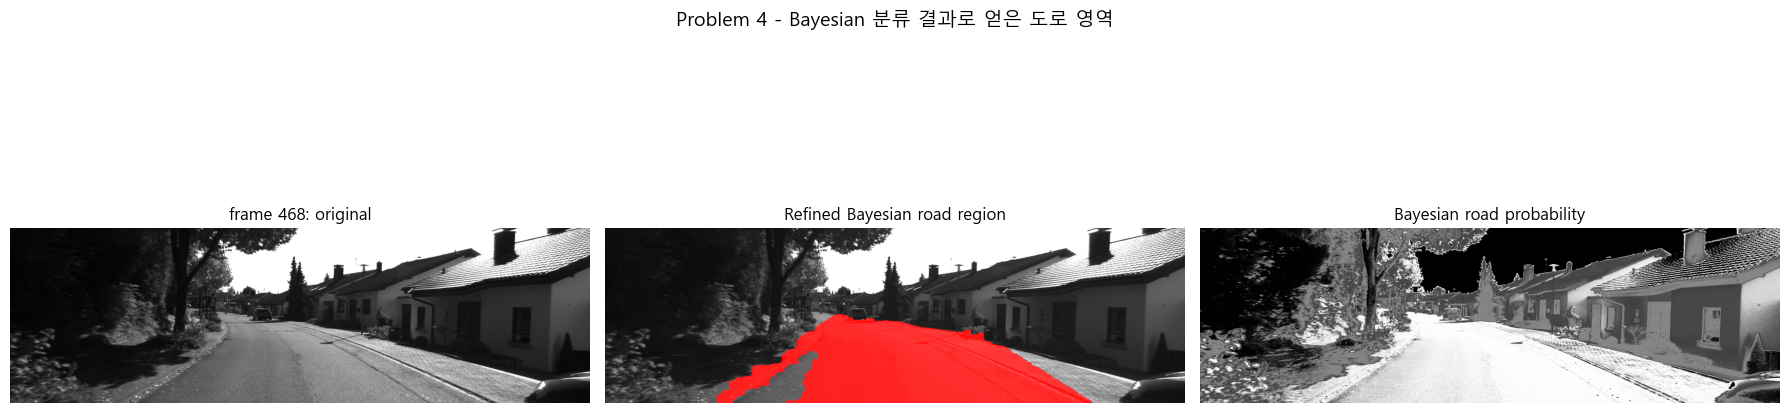

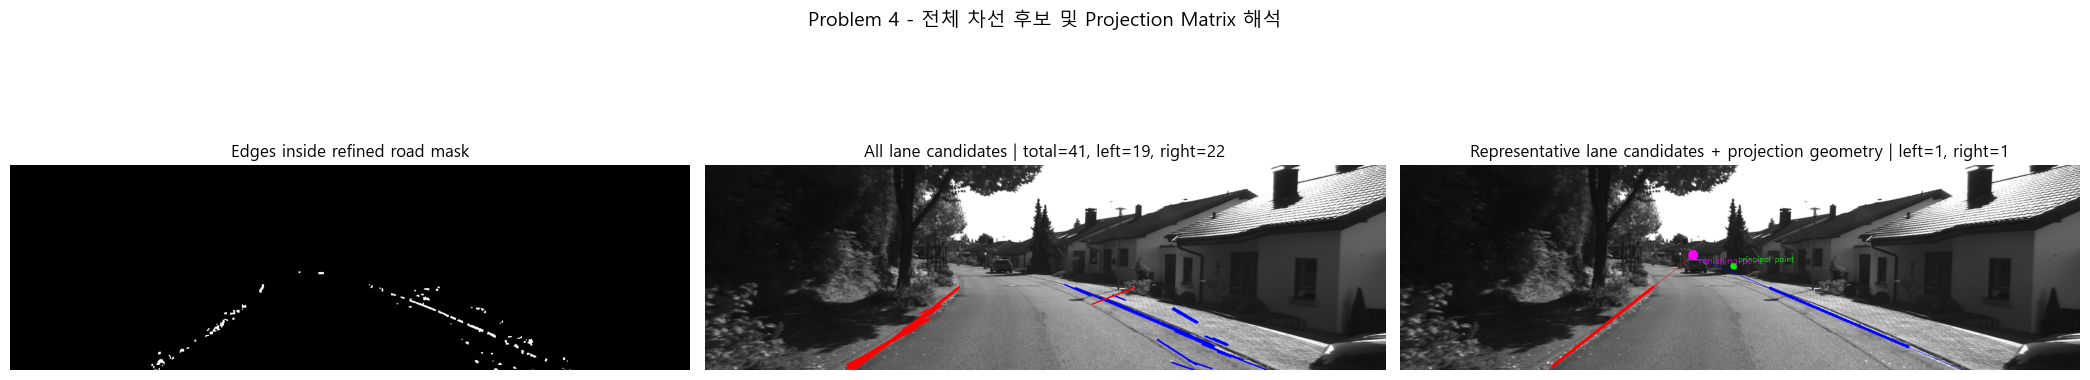

In [6]:
# 문제 4. Projection Matrix를 활용한 차선 해석
# + 전체 프레임 순차 처리
# + temporal consistency 반영
# + 인도/보도 오검출을 줄이기 위한 narrow ROI 추가
# + 전체 차선 후보 표시 추가
# + Hough 후보 중 대표 차선 후보만 선택해서 표시
# + Canny edge와 밝은 차선 반응의 AND 기반 완화


from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

try:
    import cv2
except Exception as e:
    raise RuntimeError("OpenCV(cv2)가 필요합니다. pip install opencv-python") from e



# 0. 경로 및 실행 설정
SEQUENCE = "09"
CAMERA_ID = 0

GRAY_DATASET_DIR = Path(r"C:\Users\김수연\Desktop\data_odometry_gray\dataset")
SEQ_DIR = GRAY_DATASET_DIR / "sequences" / SEQUENCE
IMG_DIR = SEQ_DIR / f"image_{CAMERA_ID}"
CALIB_PATH = SEQ_DIR / "calib.txt"

# 1번 도로 검출 코드와 같은 Bayesian 설정
PRIOR_ROAD = 0.5
ALPHA = 0.85


# 빠른 테스트를 원하면 예: MAX_FRAMES = 300
MAX_FRAMES = None

# ground plane 해석용 근사 카메라 높이
CAMERA_HEIGHT_M = 1.65

# 문제 4 차선 후보 추출용 도로 폭 제한
NARROW_BOTTOM_WIDTH_RATE = 0.68
NARROW_TOP_WIDTH_RATE = 0.10
NARROW_VP_Y_RATE = 0.50

# 대표 후보를 좌/우 몇 개씩 표시할지
REP_MAX_PER_SIDE = 1

# 밝은 차선 후보 threshold
BRIGHT_PERCENTILE = 90

print("IMG_DIR:", IMG_DIR)
print("CALIB_PATH:", CALIB_PATH)
print("IMG_DIR 존재:", IMG_DIR.exists())
print("CALIB_PATH 존재:", CALIB_PATH.exists())



# 1.  도로 검출 코드 기반 함수

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))


def read_gray_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)


def get_trapezoid_mask(
    width: int,
    height: int,
    vp_y_rate=0.5,
    bottom_width_rate=0.9,
    top_width_rate=0.15,
):
    """
    사다리꼴 ROI.
    도로는 아래쪽에서 넓고 위쪽으로 갈수록 좁아진다고 가정한다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)

    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate / 2)), height - 1]
    p4 = [int(width * (0.5 - bottom_width_rate / 2)), height - 1]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)

    return mask


def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    마스크 영역 내부 픽셀 밝기값으로 1D histogram 생성.
    """
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)


def classify_frame(
    img: np.ndarray,
    road_p: np.ndarray,
    bg_p: np.ndarray,
    prior_road: float,
):
    """
    Bayesian 방식으로 각 픽셀이 road인지 background인지 분류한다.
    """
    eps = 1e-10

    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1.0 - prior_road)

    logit = log_p_road - log_p_bg

    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0

    return mask, prob


def make_road_overlay(gray: np.ndarray, road_mask: np.ndarray):
    """
    road mask 영역을 원본 이미지 위에 빨간색으로 표시.
    """
    overlay = np.stack([gray, gray, gray], axis=-1).copy()
    road_mask = road_mask.astype(bool)

    overlay[road_mask, 0] = 255
    overlay[road_mask, 1:] = (overlay[road_mask, 1:] * 0.3).astype(np.uint8)

    return overlay



# 2. Projection Matrix / Camera Geometry 함수

def read_kitti_calib(calib_path: Path) -> dict:
    """
    KITTI calib.txt에서 P0, P1, P2, P3 projection matrix 읽기.
    """
    if not calib_path.exists():
        raise FileNotFoundError(f"calib.txt를 찾을 수 없습니다: {calib_path}")

    calib = {}

    with open(calib_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line or ":" not in line:
                continue

            key, values = line.split(":", 1)
            nums = np.array([float(x) for x in values.split()], dtype=np.float64)

            if nums.size == 12:
                calib[key] = nums.reshape(3, 4)

    return calib


def extract_intrinsic_from_projection(P: np.ndarray):
    """
    KITTI rectified projection matrix P에서 intrinsic K를 근사 추출.
    P[:, :3]을 K로 사용한다.
    """
    K = P[:, :3].copy()

    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    return K, fx, fy, cx, cy


def pixel_to_camera_ray(u: float, v: float, K: np.ndarray):
    """
    이미지 좌표 (u, v)를 카메라 좌표계 ray 방향으로 변환.
    ray = K^{-1} [u, v, 1]^T
    """
    pix = np.array([u, v, 1.0], dtype=np.float64)
    ray = np.linalg.inv(K) @ pix

    norm = np.linalg.norm(ray)

    if norm > 1e-9:
        ray = ray / norm

    return ray


def pixel_to_ground_point(
    u: float,
    v: float,
    K: np.ndarray,
    camera_height: float = 1.65,
):
    """
    ground plane 가정하에 이미지 점을 카메라 좌표계의 지면점으로 근사 변환.
    """
    ray = pixel_to_camera_ray(u, v, K)

    if ray[1] <= 1e-9:
        return None

    t = camera_height / ray[1]

    return t * ray


def vanishing_point_to_camera_direction(vp, K: np.ndarray):
    """
    소실점을 카메라 좌표계의 방향 벡터로 해석한다.
    """
    if vp is None:
        return None

    vx, vy = vp
    return pixel_to_camera_ray(vx, vy, K)



# 3. 문제 4용 도로 영역 정제

def refine_road_mask_for_lane(
    road_mask: np.ndarray,
    road_prob: np.ndarray,
    base_road_roi: np.ndarray,
):
    """
    Bayesian 분류 결과를 문제 4 차선 후보 추출에 맞게 정리한다.
    """
    h, w = road_prob.shape

    roi = (base_road_roi > 0).astype(np.uint8)

    # 인도/보도까지 road로 잡히는 것을 줄이기 위해
    # 차선 후보 추출용 도로 폭을 더 좁힌 사다리꼴 ROI 추가 적용
    narrow_roi = get_trapezoid_mask(
        w,
        h,
        vp_y_rate=NARROW_VP_Y_RATE,
        bottom_width_rate=NARROW_BOTTOM_WIDTH_RATE,
        top_width_rate=NARROW_TOP_WIDTH_RATE,
    )

    roi = (roi & narrow_roi).astype(np.uint8)

    # 위쪽 배경 제거
    roi[:int(h * 0.43), :] = 0

    # 좌우 극단부 제거
    roi[:, :int(w * 0.02)] = 0
    roi[:, int(w * 0.98):] = 0

    vals = road_prob[roi > 0]

    if len(vals) > 0:
        prob_thr = max(0.38, float(np.quantile(vals, 0.32)))
    else:
        prob_thr = 0.50

    # Bayesian MAP mask + probability threshold + 사다리꼴 ROI
    raw = (
        (roi > 0)
        &
        (
            (road_mask > 0)
            |
            (road_prob >= prob_thr)
        )
    ).astype(np.uint8)

    roi_area = np.sum(roi)
    raw_area = np.sum(raw)

    # 너무 작게 잡히면 완화
    if roi_area > 0 and raw_area < 0.35 * roi_area:
        prob_thr = max(0.34, float(np.quantile(vals, 0.22)))
        raw = ((roi > 0) & (road_prob >= prob_thr)).astype(np.uint8)

    # 너무 크게 잡히면 강화
    if roi_area > 0 and raw_area > 0.92 * roi_area:
        prob_thr = max(0.45, float(np.quantile(vals, 0.42)))
        raw = ((roi > 0) & (road_prob >= prob_thr)).astype(np.uint8)

    # morphology 정리
    cleaned = cv2.morphologyEx(
        raw,
        cv2.MORPH_CLOSE,
        np.ones((15, 15), np.uint8),
    )

    cleaned = cv2.morphologyEx(
        cleaned,
        cv2.MORPH_OPEN,
        np.ones((5, 5), np.uint8),
    )

    # 하단 중앙과 연결된 component 중심으로 유지
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        cleaned,
        connectivity=8,
    )

    if num_labels <= 1:
        return cleaned.astype(bool), raw.astype(bool), prob_thr

    seed = np.zeros_like(cleaned, dtype=np.uint8)
    seed[int(h * 0.68):h, int(w * 0.12):int(w * 0.88)] = 1

    keep_labels = []

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        _, cy_comp = centroids[label]

        component = labels == label
        touches_seed = np.any(component & (seed > 0))
        is_lower = cy_comp >= h * 0.55

        if area >= 250 and (touches_seed or is_lower):
            keep_labels.append(label)

    if len(keep_labels) > 0:
        refined = np.isin(labels, keep_labels).astype(np.uint8)
    else:
        refined = cleaned

    # 차선 edge가 잘리지 않도록 약간 확장
    refined = cv2.dilate(
        refined,
        np.ones((5, 5), np.uint8),
        iterations=1,
    )

    return refined.astype(bool), raw.astype(bool), prob_thr


# 4. 차선 후보 추출 함수

def extract_lane_candidates(
    gray: np.ndarray,
    refined_road_mask: np.ndarray,
):
    road_region = refined_road_mask.astype(np.uint8)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8, 8))
    enhanced = clahe.apply(blur)

    # 일반 edge
    edges_normal = cv2.Canny(enhanced, 45, 140)

    # 밝은 차선 성분 강조
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

    vals = tophat[road_region > 0]

    if len(vals) > 0:
        bright_thr = max(16, float(np.percentile(vals, BRIGHT_PERCENTILE)))
    else:
        bright_thr = 22

    edges_bright = ((tophat >= bright_thr) & (road_region > 0)).astype(np.uint8) * 255

    # 일반 edge와 밝은 차선 반응이 동시에 있는 부분만 우선 사용
    edges_and = cv2.bitwise_and(edges_normal, edges_bright)

    # road 영역 내부 edge만 사용
    edges_in_road = (edges_and * road_region).astype(np.uint8)

    # 너무 적게 잡히면 밝은 차선 반응만 사용
    if np.sum(edges_in_road > 0) < 30:
        edges_in_road = (edges_bright * road_region).astype(np.uint8)

    # 너무 끊어진 선을 조금 연결
    edges_in_road = cv2.morphologyEx(
        edges_in_road,
        cv2.MORPH_CLOSE,
        np.ones((3, 3), np.uint8),
    )

    edges_in_road = cv2.morphologyEx(
        edges_in_road,
        cv2.MORPH_OPEN,
        np.ones((2, 2), np.uint8),
    )

    lines = cv2.HoughLinesP(
        edges_in_road,
        rho=1,
        theta=np.pi / 180,
        threshold=15,
        minLineLength=22,
        maxLineGap=45,
    )

    return edges_in_road, lines


def filter_lane_lines(
    lines,
    image_width: int,
    image_height: int,
):
    """
    HoughLinesP 결과 중 차선 후보로 볼 수 있는 선분만 남긴다.
    """
    lane_lines = []

    if lines is None:
        return lane_lines

    w = image_width
    h = image_height

    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        if abs(dx) < 1:
            continue

        slope = dy / dx
        abs_slope = abs(slope)

        # 너무 수평인 도로 질감 제거
        if abs_slope < 0.25:
            continue

        # 너무 수직인 나무/표지판 edge 제거
        if abs_slope > 8.0:
            continue

        length = math.sqrt(dx * dx + dy * dy)

        if length < 20:
            continue

        # 너무 위쪽 edge 제거
        if max(y1, y2) < h * 0.43:
            continue

        mid_x = (x1 + x2) / 2

        if slope < 0 and mid_x < w * 0.68:
            side = "left"
        elif slope > 0 and mid_x > w * 0.32:
            side = "right"
        else:
            continue

        lane_lines.append({
            "points": (int(x1), int(y1), int(x2), int(y2)),
            "slope": float(slope),
            "length": float(length),
            "side": side,
        })

    return lane_lines


def choose_representative_lane_lines(
    lane_lines,
    image_width: int,
    image_height: int,
    max_per_side: int = 1,
):
    """
    Hough로 검출된 여러 차선 후보 중 문제 4 시각화와
    projection geometry 해석에 사용할 대표 후보만 선택한다.
    """
    left = []
    right = []

    h = image_height
    w = image_width

    for item in lane_lines:
        x1, y1, x2, y2 = item["points"]
        slope = item["slope"]
        length = item["length"]

        mid_x = (x1 + x2) / 2
        max_y = max(y1, y2)

        # 너무 짧은 선분 제거
        if length < 35:
            continue

        # 너무 위쪽에만 있는 선분 제거
        if max_y < h * 0.55:
            continue

        # 중앙부의 짧은 그림자/노면 무늬 제거
        if h * 0.55 < max_y < h * 0.75 and length < 60:
            continue

        # 왼쪽 차선 후보
        if slope < -0.25 and mid_x < w * 0.65:
            rep_score = length + 0.8 * max_y - 0.2 * abs(mid_x - w * 0.35)
            new_item = dict(item)
            new_item["rep_score"] = float(rep_score)
            left.append(new_item)

        # 오른쪽 차선 후보
        elif slope > 0.25 and mid_x > w * 0.35:
            rep_score = length + 0.8 * max_y - 0.2 * abs(mid_x - w * 0.65)
            new_item = dict(item)
            new_item["rep_score"] = float(rep_score)
            right.append(new_item)

    left = sorted(left, key=lambda x: x["rep_score"], reverse=True)[:max_per_side]
    right = sorted(right, key=lambda x: x["rep_score"], reverse=True)[:max_per_side]

    return left + right


def estimate_vanishing_point(lane_lines):
    """
    차선 후보 선분들의 교차 경향으로 소실점 추정.
    """
    if len(lane_lines) < 2:
        return None

    A = []
    b = []

    for item in lane_lines:
        x1, y1, x2, y2 = item["points"]

        a = y1 - y2
        bb = x2 - x1
        c = x1 * y2 - x2 * y1

        norm = np.sqrt(a * a + bb * bb)

        if norm < 1e-6:
            continue

        A.append([a / norm, bb / norm])
        b.append(-c / norm)

    if len(A) < 2:
        return None

    A = np.array(A, dtype=np.float64)
    b = np.array(b, dtype=np.float64)

    vp, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    return vp


def collect_ground_points(lane_lines, K: np.ndarray, camera_height=1.65):
    """
    차선 후보 선분의 양 끝점을 ground plane 위의 3D 점으로 근사.
    """
    result = []

    for item in lane_lines:
        x1, y1, x2, y2 = item["points"]

        p1 = pixel_to_ground_point(x1, y1, K, camera_height)
        p2 = pixel_to_ground_point(x2, y2, K, camera_height)

        if p1 is None or p2 is None:
            continue

        result.append({
            "side": item["side"],
            "image_points": ((x1, y1), (x2, y2)),
            "ground_points": (p1, p2),
        })

    return result


# 4-1. 시각화 함수

def draw_all_lane_candidates_overlay(
    gray: np.ndarray,
    lane_lines_all,
):
    """
    필터링된 전체 차선 후보를 원본 이미지 위에 모두 표시한다.
    왼쪽 후보는 빨간색, 오른쪽 후보는 파란색으로 표시한다.
    """
    overlay = np.stack([gray, gray, gray], axis=-1).copy()

    for item in lane_lines_all:
        x1, y1, x2, y2 = item["points"]

        if item["side"] == "left":
            color = (255, 0, 0)
        else:
            color = (0, 0, 255)

        cv2.line(overlay, (x1, y1), (x2, y2), color, 2)

    return overlay


def draw_lane_overlay(
    gray: np.ndarray,
    lane_lines,
    principal_point=None,
    vanishing_point=None,
):
    """
    원본 이미지 위에 대표 차선 후보, principal point, vanishing point 표시.
    """
    overlay = np.stack([gray, gray, gray], axis=-1).copy()
    h, w = gray.shape

    for item in lane_lines:
        x1, y1, x2, y2 = item["points"]

        if item["side"] == "left":
            color = (255, 0, 0)
        else:
            color = (0, 0, 255)

        # 실제 검출된 대표 선분
        cv2.line(overlay, (x1, y1), (x2, y2), color, 3)

        # 선분 방향을 조금 연장해서 차선 방향이 더 잘 보이게 표시
        dx = x2 - x1
        dy = y2 - y1

        if abs(dx) > 1:
            slope = dy / dx

            if abs(slope) > 1e-6:
                if y1 > y2:
                    xb, yb = x1, y1
                else:
                    xb, yb = x2, y2

                y_bottom = h - 1
                x_bottom = int(xb + (y_bottom - yb) / slope)

                if y1 < y2:
                    xt, yt = x1, y1
                else:
                    xt, yt = x2, y2

                y_top = max(int(h * 0.45), yt - 80)
                x_top = int(xt + (y_top - yt) / slope)

                if -w <= x_bottom <= 2 * w and -w <= x_top <= 2 * w:
                    cv2.line(
                        overlay,
                        (x_bottom, y_bottom),
                        (x_top, y_top),
                        color,
                        1,
                    )

    if principal_point is not None:
        pcx, pcy = principal_point

        if 0 <= pcx < w and 0 <= pcy < h:
            cv2.circle(overlay, (int(pcx), int(pcy)), 6, (0, 255, 0), -1)
            cv2.putText(
                overlay,
                "principal point",
                (int(pcx) + 8, int(pcy) - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 255, 0),
                1,
            )

    if vanishing_point is not None:
        vx, vy = vanishing_point

        if 0 <= vx < w and 0 <= vy < h:
            cv2.circle(overlay, (int(vx), int(vy)), 9, (255, 0, 255), -1)
            cv2.putText(
                overlay,
                "vanishing point",
                (int(vx) + 8, int(vy) + 15),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 255),
                1,
            )

    return overlay


# 5. 대표 프레임 점수 계산 함수

def score_result(
    refined_road_mask,
    road_prob,
    base_road_roi,
    lane_edges,
    lane_lines,
    vanishing_point,
    image_width,
    image_height,
):
    """
    문제 4 대표 프레임 자동 선택용 점수.
    여기서는 대표 차선 후보 기준으로 점수를 계산한다.
    """
    h = image_height
    w = image_width

    score = 0.0

    road = refined_road_mask.astype(bool)
    roi = base_road_roi.astype(bool)

    valid_roi = roi.copy()
    valid_roi[:int(h * 0.43), :] = False

    roi_area = np.sum(valid_roi)
    road_area = np.sum(road & valid_roi)

    if roi_area > 0:
        road_ratio = road_area / roi_area
    else:
        road_ratio = 0.0

    if 0.30 <= road_ratio <= 0.68:
        score += 80
    elif 0.22 <= road_ratio < 0.30 or 0.68 < road_ratio <= 0.78:
        score += 30
    else:
        score -= 80

    bottom_center = np.zeros_like(road, dtype=bool)
    bottom_center[int(h * 0.70):h, int(w * 0.20):int(w * 0.80)] = True

    bottom_area = np.sum(bottom_center)
    bottom_road_area = np.sum(road & bottom_center)

    if bottom_area > 0:
        bottom_coverage = bottom_road_area / bottom_area
    else:
        bottom_coverage = 0.0

    if bottom_coverage >= 0.45:
        score += 80
    elif bottom_coverage >= 0.25:
        score += 30
    else:
        score -= 100

    if np.sum(road) > 0:
        mean_prob_inside = float(np.mean(road_prob[road]))
    else:
        mean_prob_inside = 0.0

    if mean_prob_inside >= 0.55:
        score += 40
    elif mean_prob_inside >= 0.45:
        score += 15
    else:
        score -= 40

    left = [x for x in lane_lines if x["side"] == "left"]
    right = [x for x in lane_lines if x["side"] == "right"]

    lane_count = len(lane_lines)
    left_count = len(left)
    right_count = len(right)

    if lane_count == 0:
        score -= 200
    elif lane_count == 1:
        score += 10
    elif 2 <= lane_count <= 3:
        score += 80
    else:
        score -= (lane_count - 3) * 15

    if left_count > 0 and right_count > 0:
        score += 100
    elif left_count > 0 or right_count > 0:
        score += 30
    else:
        score -= 80

    total_length = sum(x["length"] for x in lane_lines)
    score += min(total_length, 600) * 0.05

    road_pixels = np.sum(road)
    edge_pixels = np.sum(lane_edges > 0)

    if road_pixels > 0:
        edge_density = edge_pixels / road_pixels
    else:
        edge_density = 0.0

    if 0.003 <= edge_density <= 0.080:
        score += 40
    elif edge_density > 0.12:
        score -= 80
    else:
        score -= 20

    lower_touch_count = 0

    for item in lane_lines:
        x1, y1, x2, y2 = item["points"]

        if max(y1, y2) > h * 0.62:
            lower_touch_count += 1

    score += min(lower_touch_count, 3) * 12

    if vanishing_point is not None:
        vx, vy = vanishing_point

        if 0.20 * w <= vx <= 0.80 * w and 0.15 * h <= vy <= 0.75 * h:
            score += 100
        elif 0.00 * w <= vx <= 1.00 * w and 0.05 * h <= vy <= 0.90 * h:
            score += 30
        else:
            score -= 100

        if vy > 0.85 * h:
            score -= 100
    else:
        score -= 40

    return score



# 6. 전체 프레임 처리 + 대표 프레임 선택

def run_problem4_show_only(
    data_root: Path,
    calib_path: Path,
    prior_road: float,
    alpha: float = 0.85,
    max_frames: int | None = None,
):
    """
    - 모든 프레임을 순차적으로 처리한다.
    - 매 프레임마다 temporal consistency를 반영한다.
    - 전체 차선 후보를 추출한다.
    - Hough 후보 중 대표 후보만 선택한다.
    - 대표 후보를 기준으로 score와 vanishing point를 계산한다.
    - 가장 점수가 높은 대표 프레임 1개만 반환한다.
    """
    frames = list_frames(data_root)

    if not frames:
        raise RuntimeError(f"No PNG frames found in {data_root}")

    sample_img = read_gray_image(frames[0])
    h, w = sample_img.shape

    road_roi = get_trapezoid_mask(w, h)
    bg_roi = 1 - road_roi

    road_p_total = np.ones(256, dtype=np.float64)
    bg_p_total = np.ones(256, dtype=np.float64)

    calib = read_kitti_calib(calib_path)
    P_KEY = f"P{CAMERA_ID}"

    if P_KEY not in calib:
        raise KeyError(f"{P_KEY}를 calib.txt에서 찾을 수 없습니다. 현재 key: {list(calib.keys())}")

    P = calib[P_KEY]
    K, fx, fy, cx, cy = extract_intrinsic_from_projection(P)

    print("\n[Projection Matrix]")
    print("사용한 matrix:", P_KEY)
    print(P)
    print(f"fx={fx:.3f}, fy={fy:.3f}, cx={cx:.3f}, cy={cy:.3f}")

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))

    best_result = None
    best_score = -1e18

    for idx, path in enumerate(frames[:limit]):
        img = read_gray_image(path)

        # 현재 프레임 road/background histogram 계산
        curr_road_counts = accumulate_weighted_histogram(img, road_roi)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_roi)

        # temporal consistency 적용
        if idx == 0:
            road_p_total = curr_road_counts + 1.0
            bg_p_total = curr_bg_counts + 1.0
        else:
            road_p_total = alpha * road_p_total + (1.0 - alpha) * (curr_road_counts + 1.0)
            bg_p_total = alpha * bg_p_total + (1.0 - alpha) * (curr_bg_counts + 1.0)

        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # Bayesian road/background 분류
        mask, prob = classify_frame(img, road_p, bg_p, prior_road)

        # 문제 4: Bayesian 결과를 차선 후보 추출에 맞게 정제
        refined_road_mask, threshold_road_mask, used_thr = refine_road_mask_for_lane(
            mask,
            prob,
            road_roi,
        )

        # 문제 4: 도로 영역 내부에서 Hough 후보 추출
        lane_edges, raw_lines = extract_lane_candidates(
            img,
            refined_road_mask,
        )

        # 전체 차선 후보
        lane_lines_all = filter_lane_lines(
            raw_lines,
            image_width=w,
            image_height=h,
        )

        # 대표 후보만 선택
        lane_lines = choose_representative_lane_lines(
            lane_lines_all,
            image_width=w,
            image_height=h,
            max_per_side=REP_MAX_PER_SIDE,
        )

        # 소실점도 대표 후보 기준으로 계산
        vanishing_point = estimate_vanishing_point(lane_lines)

        principal_point = (cx, cy)
        principal_ray = pixel_to_camera_ray(cx, cy, K)

        if vanishing_point is not None:
            vanishing_point_ray = vanishing_point_to_camera_direction(vanishing_point, K)
        else:
            vanishing_point_ray = None

        ground_points = collect_ground_points(
            lane_lines,
            K,
            camera_height=CAMERA_HEIGHT_M,
        )

        left_count = sum(1 for x in lane_lines if x["side"] == "left")
        right_count = sum(1 for x in lane_lines if x["side"] == "right")

        all_left_count = sum(1 for x in lane_lines_all if x["side"] == "left")
        all_right_count = sum(1 for x in lane_lines_all if x["side"] == "right")

        score = score_result(
            refined_road_mask=refined_road_mask,
            road_prob=prob,
            base_road_roi=road_roi,
            lane_edges=lane_edges,
            lane_lines=lane_lines,
            vanishing_point=vanishing_point,
            image_width=w,
            image_height=h,
        )

        if score > best_score:
            road_overlay = make_road_overlay(img, mask)
            refined_overlay = make_road_overlay(img, refined_road_mask)

            all_lane_overlay = draw_all_lane_candidates_overlay(
                img,
                lane_lines_all,
            )

            lane_overlay = draw_lane_overlay(
                img,
                lane_lines,
                principal_point=principal_point,
                vanishing_point=vanishing_point,
            )

            best_score = score
            best_result = {
                "idx": idx,
                "stem": path.stem,
                "path": str(path),
                "img": img,
                "mask": mask,
                "prob": prob,
                "road_overlay": road_overlay,
                "refined_road_mask": refined_road_mask,
                "refined_overlay": refined_overlay,
                "lane_edges": lane_edges,
                "raw_lines": raw_lines,
                "lane_lines_all": lane_lines_all,
                "all_lane_overlay": all_lane_overlay,
                "lane_lines": lane_lines,
                "lane_overlay": lane_overlay,
                "used_thr": used_thr,
                "all_left_count": all_left_count,
                "all_right_count": all_right_count,
                "left_count": left_count,
                "right_count": right_count,
                "score": score,
                "principal_point": principal_point,
                "principal_ray": principal_ray,
                "vanishing_point": vanishing_point,
                "vanishing_point_ray": vanishing_point_ray,
                "ground_points": ground_points,
                "P_key": P_KEY,
                "P": P,
                "K": K,
                "fx": fx,
                "fy": fy,
                "cx": cx,
                "cy": cy,
            }

        if idx % 20 == 0 or idx == limit - 1:
            print(
                f"Processed frame {idx:4d}/{limit - 1:4d} | "
                f"score={score:7.2f} | "
                f"Hough={0 if raw_lines is None else len(raw_lines):3d} | "
                f"all_lane={len(lane_lines_all):2d} | "
                f"rep_lane={len(lane_lines):2d} | "
                f"left={left_count:2d}, right={right_count:2d}"
            )

    if best_result is None:
        raise RuntimeError("대표 프레임을 선택하지 못했습니다.")

    return best_result



# 7. 실행
best_result = run_problem4_show_only(
    data_root=IMG_DIR,
    calib_path=CALIB_PATH,
    prior_road=PRIOR_ROAD,
    alpha=ALPHA,
    max_frames=MAX_FRAMES,
)



# 8. 대표 프레임 정보 출력

print("\n[문제 4 대표 프레임 선택 결과]")
print("선택된 frame index:", best_result["idx"])
print("선택된 frame path:", best_result["path"])
print("score:", round(best_result["score"], 2))

print("\n[차선 후보 추출 결과]")
print("전체 1차 차선 후보 개수:", len(best_result["lane_lines_all"]))
print("전체 left 후보 개수:", best_result["all_left_count"])
print("전체 right 후보 개수:", best_result["all_right_count"])
print("대표 차선 후보 개수:", len(best_result["lane_lines"]))
print("left 대표 후보 개수:", best_result["left_count"])
print("right 대표 후보 개수:", best_result["right_count"])

print("\n[Projection Matrix 기반 계산]")
print(f"principal point: ({best_result['cx']:.1f}, {best_result['cy']:.1f})")

pr = best_result["principal_ray"]
print(f"principal point의 camera ray: [{pr[0]:.4f}, {pr[1]:.4f}, {pr[2]:.4f}]")

vp = best_result["vanishing_point"]
vp_ray = best_result["vanishing_point_ray"]

if vp is not None:
    print(f"estimated vanishing point: ({vp[0]:.1f}, {vp[1]:.1f})")
    print(f"vanishing point camera direction: [{vp_ray[0]:.4f}, {vp_ray[1]:.4f}, {vp_ray[2]:.4f}]")
else:
    print("estimated vanishing point: 추정 불가")

print("ground plane으로 변환 가능한 대표 차선 후보 segment 수:", len(best_result["ground_points"]))

if len(best_result["ground_points"]) > 0:
    ex = best_result["ground_points"][0]
    p1, p2 = ex["ground_points"]

    print("\n[Ground plane 근사 예시]")
    print("side:", ex["side"])
    print("image points:", ex["image_points"])
    print(f"ground point 1 [X,Y,Z] = [{p1[0]:.2f}, {p1[1]:.2f}, {p1[2]:.2f}] m")
    print(f"ground point 2 [X,Y,Z] = [{p2[0]:.2f}, {p2[1]:.2f}, {p2[2]:.2f}] m")



# 9. 대표 프레임 시각화
# 9-1. Bayesian 도로 영역 결과
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(best_result["img"], cmap="gray")
axes[0].set_title(f"frame {best_result['idx']}: original")
axes[0].axis("off")

axes[1].imshow(best_result["refined_overlay"])
axes[1].set_title("Refined Bayesian road region")
axes[1].axis("off")

axes[2].imshow(best_result["prob"], cmap="gray")
axes[2].set_title("Bayesian road probability")
axes[2].axis("off")

plt.suptitle("Problem 4 - Bayesian 분류 결과로 얻은 도로 영역", fontsize=14)
plt.tight_layout()
plt.show()


# 9-2. Edge + 전체 차선 후보 + 대표 차선 후보
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].imshow(best_result["lane_edges"], cmap="gray")
axes[0].set_title("Edges inside refined road mask")
axes[0].axis("off")

axes[1].imshow(best_result["all_lane_overlay"])
axes[1].set_title(
    f"All lane candidates | "
    f"total={len(best_result['lane_lines_all'])}, "
    f"left={best_result['all_left_count']}, "
    f"right={best_result['all_right_count']}"
)
axes[1].axis("off")

axes[2].imshow(best_result["lane_overlay"])
axes[2].set_title(
    f"Representative lane candidates + projection geometry | "
    f"left={best_result['left_count']}, right={best_result['right_count']}"
)
axes[2].axis("off")

plt.suptitle("Problem 4 - 전체 차선 후보 및 Projection Matrix 해석", fontsize=14)
plt.tight_layout()
plt.show()

---

## 문제 4. Projection Matrix를 활용한 차선 해석 결과

본 문제에서는 Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 카메라 기하 관점에서 해석하였다.

실험에서는 KITTI sequence 09의 gray image와 calibration 파일의 `P0` projection matrix를 사용하였다. 사용한 projection matrix는 다음과 같다.

$$
P_0 =
\begin{bmatrix}
707.0912 & 0 & 601.8873 & 0 \\
0 & 707.0912 & 183.1104 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
$$

따라서 intrinsic parameter는 다음과 같이 해석된다.

- $f_x = 707.091$, $f_y = 707.091$: 카메라의 초점거리
- $c_x = 601.887$, $c_y = 183.110$: 이미지의 principal point
- $P_0$의 마지막 열이 0이므로, 본 코드에서는 rectified camera 좌표계에서 intrinsic matrix $K$를 중심으로 투영 관계를 해석하였다.

---

### 1). Bayesian 분류 결과로 얻은 도로 영역 해석

첫 번째 결과 그림은 Bayesian 분류를 통해 도로 영역을 추정한 결과이다.

- `original`은 입력된 원본 gray image이다.
- `Refined Bayesian road region`은 Bayesian 분류 결과 중 도로로 판단된 영역을 빨간색으로 표시한 것이다.
- `Bayesian road probability`는 각 픽셀이 도로일 확률을 grayscale로 나타낸 것이다. 밝을수록 도로일 확률이 높고, 어두울수록 배경일 확률이 높다.

결과에서 차량 전방의 주행 가능한 도로 영역이 주로 빨간색으로 표시되었다. 이는 Bayesian 분류기가 도로 영역과 배경 영역의 밝기 분포 차이를 이용하여 도로 후보 영역을 추정했음을 의미한다.

다만 Bayesian 분류는 픽셀 밝기 기반의 단순 확률 모델이므로, 그림자나 밝은 보도, 도로와 비슷한 밝기의 배경이 일부 포함될 수 있다. 따라서 본 코드에서는 차선 후보를 추출하기 전에 도로 영역을 사다리꼴 ROI와 morphology 연산으로 한 번 더 정제하였다.

---

### 2). 도로 영역 내부에서의 차선 후보 추출 결과

두 번째 결과 그림은 정제된 도로 영역 내부에서 차선 후보를 추출한 결과이다.

- `Edges inside refined road mask`는 Bayesian 도로 영역 내부에서 Canny edge와 밝은 차선 반응을 이용해 추출한 edge이다.
- `All lane candidates`는 Hough Transform으로 검출된 전체 차선 후보이다.
- `Representative lane candidates + projection geometry`는 전체 후보 중 대표적인 왼쪽/오른쪽 차선 후보만 선택하고, principal point와 vanishing point를 함께 표시한 결과이다.

실험 결과 전체 차선 후보는 총 41개가 검출되었고, 이 중 왼쪽 후보는 19개, 오른쪽 후보는 22개였다. 이후 기울기, 위치, 길이 등을 기준으로 대표 차선 후보를 선택한 결과, 왼쪽 대표 차선 1개와 오른쪽 대표 차선 1개가 선택되었다.

이 결과는 Bayesian 분류로 얻은 도로 영역을 먼저 제한 영역으로 사용한 뒤, 그 안에서만 차선 후보를 찾았다. 즉, 전체 이미지에서 무작정 선분을 찾은 것이 아니라, 도로로 추정된 영역 내부에서 차선 후보를 추출하였다.

---

### 3). 이미지 좌표에서 검출된 차선의 카메라 좌표계 의미

이미지에서 검출된 차선 후보는 2D image coordinate 상의 선분이다. 예를 들어 결과에서 선택된 왼쪽 대표 차선 후보는 다음과 같은 이미지 좌표를 가진다.

$$
(u_1, v_1) = (275, 362), \quad (u_2, v_2) = (457, 220)
$$

이미지 좌표 $(u, v)$는 그 자체로 3D 위치를 직접 의미하지 않는다. 하나의 이미지 점은 카메라 중심에서 출발하여 3D 공간으로 나아가는 하나의 ray 방향을 의미한다. 이 관계는 intrinsic matrix $K$를 이용하여 다음과 같이 표현할 수 있다.

$$
\mathbf{r} =
K^{-1}
\begin{bmatrix}
u \\
v \\
1
\end{bmatrix}
$$

여기서 $\mathbf{r}$은 카메라 좌표계에서 해당 픽셀이 가리키는 방향 벡터이다. 즉, 이미지 위의 차선 선분은 카메라 좌표계에서 보면 도로 평면 위에 존재하는 3D 차선 경계선이 카메라 영상으로 투영된 결과라고 해석할 수 있다.

본 코드에서는 카메라 높이를 약 $1.65m$로 가정하고, 각 이미지 점에서 나온 ray가 ground plane과 만나는 지점을 계산하였다. 그 결과 왼쪽 대표 차선의 두 끝점은 다음과 같은 ground point로 변환되었다.

$$
P_1 = [-3.02,\ 1.65,\ 6.52]m
$$

$$
P_2 = [-6.48,\ 1.65,\ 31.63]m
$$

이를 해석하면 다음과 같다.

- $Y = 1.65m$로 동일하게 나타나는 것은 두 점이 같은 ground plane 위에 있다고 가정했기 때문이다.
- $Z$ 값이 $6.52m$에서 $31.63m$로 증가하므로, 차선 선분은 카메라 앞쪽으로 멀어지는 방향을 가진다.
- $X$ 값이 음수이므로, 해당 대표 차선은 카메라 좌표계 기준 왼쪽에 위치한 차선 후보로 해석할 수 있다.

따라서 이미지에서 단순히 기울어진 2D 선으로 보이는 차선은 실제 카메라 좌표계에서는 지면 위에 놓인 3D 직선 구조가 원근 투영된 결과이다.

---

### 4). 도로를 ground plane으로 가정했을 때의 차선 기하 특성

도로를 하나의 평면, 즉 ground plane으로 가정하면 차선은 다음과 같은 기하적 특성을 가진다.

1. 실제 3D 공간에서 차선은 도로 평면 위에 놓인 직선 또는 거의 직선에 가까운 곡선이다.
2. 왼쪽 차선과 오른쪽 차선은 실제 도로 좌표계에서는 서로 거의 평행하다.
3. 차선 폭은 실제 3D 공간에서는 거의 일정하지만, 이미지에서는 원근 효과 때문에 멀리 있는 부분일수록 좁아 보인다.
4. 카메라에서 가까운 차선은 이미지 아래쪽에 크게 나타나고, 멀리 있는 차선은 이미지 위쪽의 지평선 방향으로 모인다.

즉, ground plane 가정하에서 차선 후보는 단순한 이미지 edge가 아니라, 카메라 앞쪽 도로 평면 위에 놓인 주행 방향 경계선으로 해석된다.

결과에서도 대표 왼쪽 차선과 오른쪽 차선이 이미지 아래쪽에서 넓게 벌어져 있고, 위쪽으로 갈수록 서로 가까워지는 형태를 보인다. 이는 도로 위의 평행한 차선들이 perspective projection에 의해 하나의 방향으로 수렴해 보이는 전형적인 결과이다.

---

### 5). Projection matrix와 차선 기울기의 관계

Projection matrix는 3D 카메라 좌표계의 점을 2D 이미지 좌표로 변환하는 역할을 한다.

$$
s
\begin{bmatrix}
u \\
v \\
1
\end{bmatrix}
=
P
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}
$$

본 실험에서 사용한 $P_0$는 rectified camera 기준으로 다음과 같이 해석할 수 있다.

$$
u = f_x \frac{X}{Z} + c_x
$$

$$
v = f_y \frac{Y}{Z} + c_y
$$

여기서 $Z$는 카메라로부터의 깊이 방향 거리이다. 따라서 같은 ground plane 위의 차선이라도 $Z$가 커질수록, 즉 멀어질수록 이미지 좌표는 principal point와 지평선 방향으로 가까워진다.

이미지에서 차선의 기울기는 다음과 같이 계산된다.

$$
m = \frac{v_2 - v_1}{u_2 - u_1}
$$

하지만 이 기울기는 실제 3D 차선의 기울기와 동일하지 않다. 실제 도로 위에서 평행한 차선도 projection matrix를 통해 이미지로 투영되면 원근 효과 때문에 서로 다른 방향의 2D 기울기를 갖게 된다.

즉, 이미지에서 보이는 차선의 기울기는 실제 차선의 방향, 카메라의 위치와 자세, 그리고 intrinsic parameter인 $f_x$, $f_y$, $c_x$, $c_y$가 함께 반영된 결과이다.

결과에서 왼쪽 차선은 음의 기울기, 오른쪽 차선은 양의 기울기를 갖는다. 이는 카메라가 도로 중앙 근처를 바라볼 때, 왼쪽 차선과 오른쪽 차선이 이미지 상에서 서로 반대 방향으로 기울어져 보이는 일반적인 원근 투영 결과이다.

---

### 6). Projection matrix와 소실점의 관계

소실점은 3D 공간에서 서로 평행한 직선들이 이미지 평면 위에서 만나는 것처럼 보이는 점이다. 도로 위의 왼쪽 차선과 오른쪽 차선은 실제 3D 공간에서는 거의 평행하지만, 이미지에서는 원근 투영 때문에 한 점으로 수렴한다.

차선 방향 벡터를 $\mathbf{d}$라고 하면, 소실점 $\mathbf{v}_{vp}$는 해당 방향의 무한히 먼 점이 이미지에 투영된 위치로 해석할 수 있다.

$$
\mathbf{v}_{vp} \sim K\mathbf{d}
$$

즉, 소실점의 위치는 카메라 intrinsic matrix $K$와 도로 위 차선의 3D 방향에 의해 결정된다.

결과에서 magenta 점으로 표시된 vanishing point는 왼쪽 대표 차선과 오른쪽 대표 차선의 연장선이 만나는 지점으로 추정되었다. 이 점은 이미지의 중앙 상단, 즉 도로가 멀어지는 방향 근처에 위치한다. 이는 실제 도로 위에서 평행한 차선들이 카메라 영상에서는 하나의 소실점 방향으로 수렴한다는 projection geometry와 일치한다.

또한 green 점으로 표시된 principal point는 $(c_x, c_y) = (601.887, 183.110)$이다. principal point는 카메라 optical axis가 이미지 평면과 만나는 기준점이다. 도로가 카메라 정면 방향으로 뻗어 있을 경우, 차선의 소실점은 principal point 근처에 형성되는 경향이 있다.

결과에서도 소실점이 이미지 중앙부 근처에 위치하므로, 차량이 대체로 도로 진행 방향을 향하고 있음을 알 수 있다.

---

### 7). 최종 해석

정리하면, 본 결과는 다음과 같이 해석할 수 있다.

Bayesian 분류를 통해 먼저 도로 영역을 추정하였고, 이 영역 내부에서 edge와 Hough Transform을 이용해 차선 후보를 추출하였다. 전체 후보 중 위치, 기울기, 길이 조건을 만족하는 대표 왼쪽 차선과 오른쪽 차선을 선택하였다.

이미지 좌표에서 검출된 차선 선분은 카메라 좌표계에서 ground plane 위에 놓인 3D 차선 경계선의 투영 결과이다. 각 이미지 점은 intrinsic matrix $K$를 이용해 카메라 ray로 변환할 수 있으며, ground plane과의 교점을 계산하면 도로 평면 위의 3D 점으로 근사할 수 있다.

또한 도로 위의 실제 차선들은 거의 평행하지만, projection matrix에 의해 이미지로 투영되면서 서로 수렴하는 것처럼 보인다. 이때 차선 연장선들이 만나는 지점이 vanishing point이며, 이는 카메라의 intrinsic parameter와 차선의 3D 진행 방향에 의해 결정된다.

---

## 문제 5. 실패 구간 분석


POSE_PATH: C:\Users\김수연\Desktop\data_odometry_poses\dataset\poses\09.txt
POSE_PATH 존재: True
Processed frame    0/1590 | score= 553.36 | severity=   0.00 | all_lane= 5 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame   50/1590 | score= 511.09 | severity=   0.00 | all_lane=30 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame  100/1590 | score= 557.93 | severity=   0.00 | all_lane= 9 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame  150/1590 | score= 215.77 | severity= 225.27 | all_lane=14 | rep_lane= 1 | left=1, right=0 | failure=True
Processed frame  200/1590 | score= 507.43 | severity=   0.00 | all_lane=21 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame  250/1590 | score= 514.71 | severity=   0.00 | all_lane=24 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame  300/1590 | score= 502.28 | severity=   0.00 | all_lane= 9 | rep_lane= 2 | left=1, right=1 | failure=False
Processed frame  350/1590 | score= 557.76 | seve

,type,frame,image,score,severity,rep_lane,rep_left,rep_right,all_lane,all_left,all_right,pose_x,pose_z,road_ratio,edge_density,brightness_std,texture_std,heading_change_deg
0,차선 후보 미검출(all_lane=0),1581,001581,-215.0,434.5,0,0,0,0,0,0,-1.13,2.03,0.714,0.0016,74.27,78.09,3.58
1,후보 존재하지만 분류 실패(all_lane>0),965,000965,-155.0,386.5,0,0,0,1,0,1,321.17,491.94,0.736,0.0071,78.44,61.45,12.77


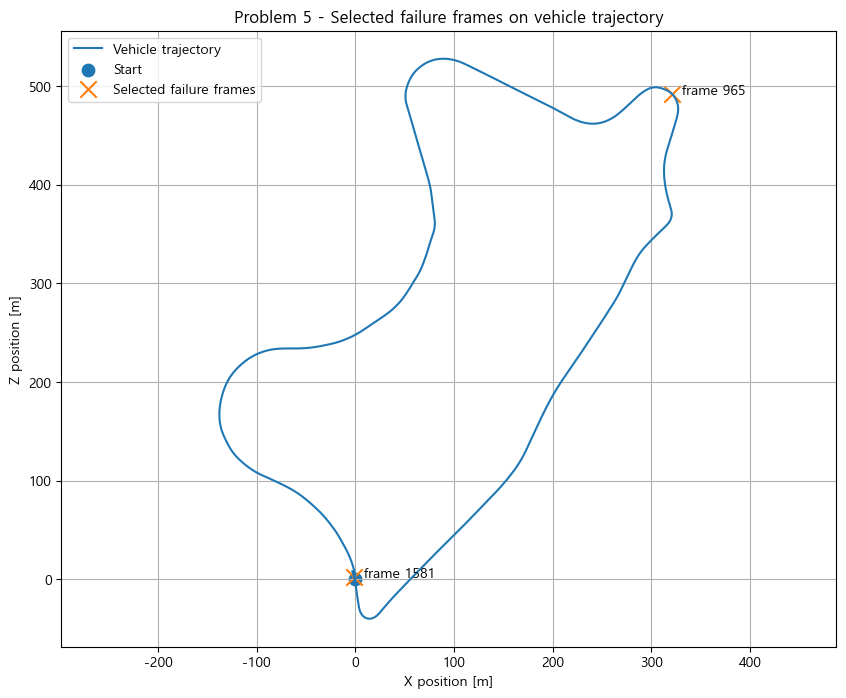

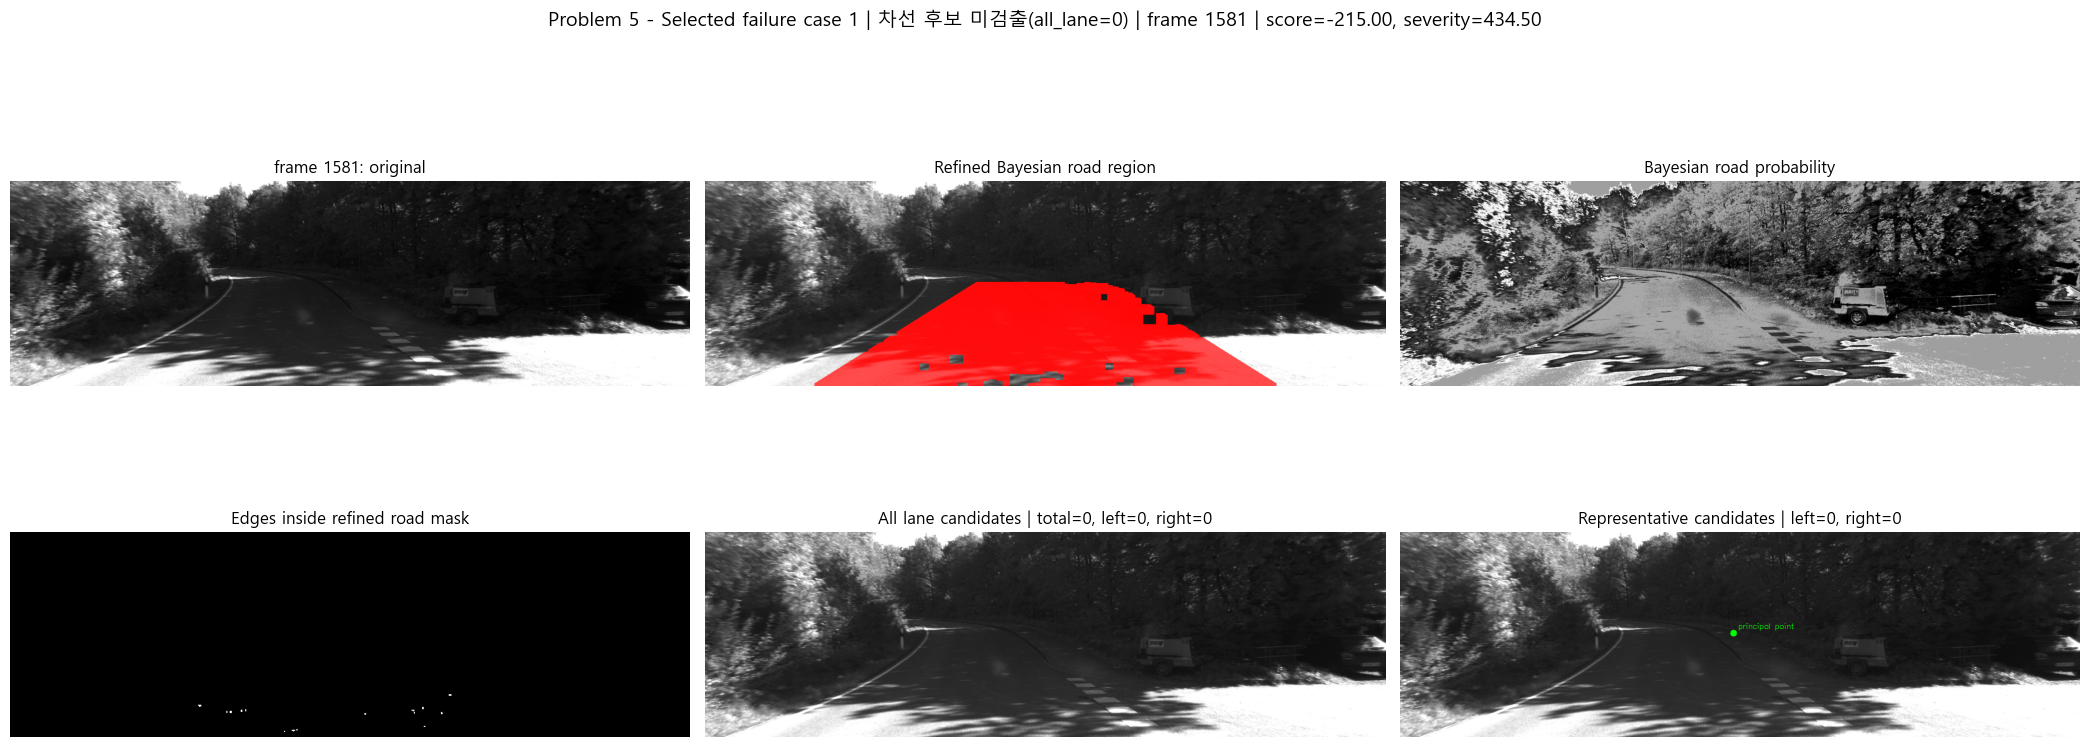

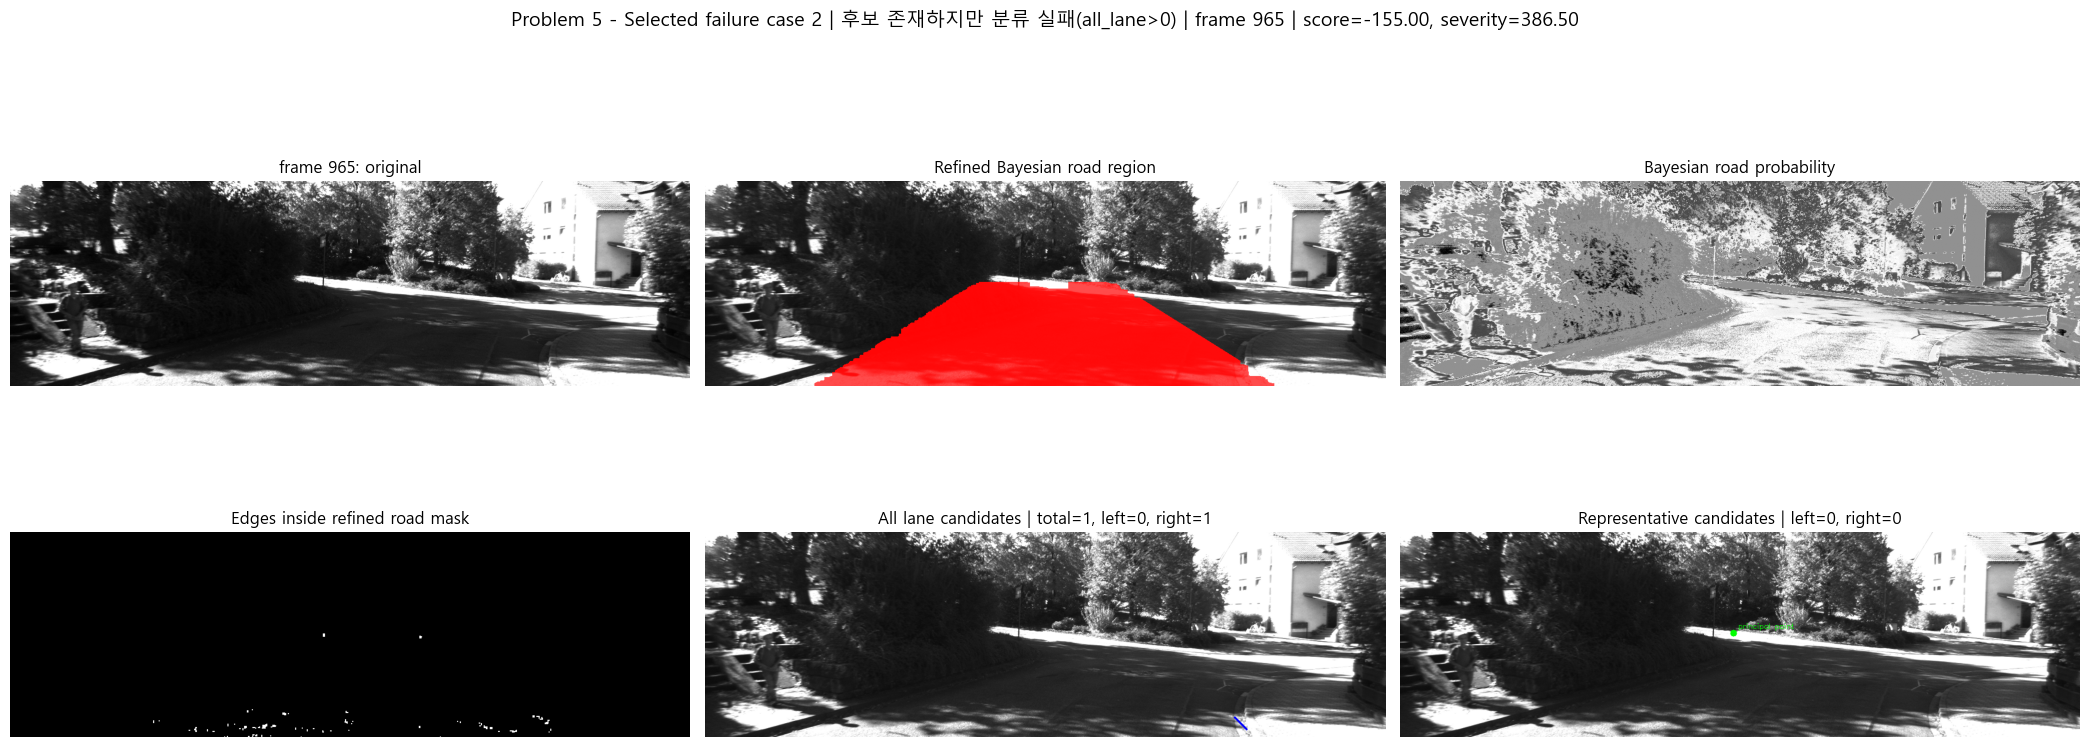

In [14]:
# ============================================================
# 문제 5. 실패 구간 분석
# - 전체 프레임 분석
# - 차선 분류가 잘 되지 않은 실패 구간 2개 선택
# ============================================================

from pathlib import Path
import math
import gc
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None



# 0. Pose 파일 경로 설정
POSE_PATH_CANDIDATES = [
    GRAY_DATASET_DIR.parent.parent / "data_odometry_poses" / "dataset" / "poses" / f"{SEQUENCE}.txt",
    Path("data_odometry_poses") / "dataset" / "poses" / f"{SEQUENCE}.txt",
    Path("dataset") / "poses" / f"{SEQUENCE}.txt",
    Path("poses") / f"{SEQUENCE}.txt",
]

POSE_PATH = None

for cand in POSE_PATH_CANDIDATES:
    if cand.exists():
        POSE_PATH = cand
        break

if POSE_PATH is None:
    POSE_PATH = POSE_PATH_CANDIDATES[0]

print("POSE_PATH:", POSE_PATH)
print("POSE_PATH 존재:", POSE_PATH.exists())

if not POSE_PATH.exists():
    raise FileNotFoundError(
        "pose 파일을 찾지 못했습니다.\n"
        "POSE_PATH를 본인 컴퓨터의 data_odometry_poses/dataset/poses/09.txt 경로로 직접 수정하세요."
    )



# 1. Bayesian classify 함수
def classify_frame_light(img, road_p, bg_p, prior_road):
    """
    기존 classify_frame보다 메모리를 적게 쓰도록 float32 중심으로 계산한다.
    """
    eps = np.float32(1e-10)

    road_lookup = road_p.astype(np.float32)
    bg_lookup = bg_p.astype(np.float32)

    log_p_road = np.log(road_lookup[img] + eps).astype(np.float32)
    log_p_bg = np.log(bg_lookup[img] + eps).astype(np.float32)

    log_p_road += np.float32(math.log(prior_road))
    log_p_bg += np.float32(math.log(1.0 - prior_road))

    logit = log_p_road - log_p_bg

    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    prob = prob.astype(np.float32)

    mask = logit > 0

    return mask, prob



# 2. KITTI pose 읽기 함수
def read_kitti_poses(pose_path: Path) -> np.ndarray:
    """
    KITTI pose 파일을 읽어서 4x4 pose matrix 배열로 변환한다.
    """
    poses = []

    with open(pose_path, "r", encoding="utf-8") as f:
        for line in f:
            values = [float(x) for x in line.strip().split()]

            if len(values) != 12:
                continue

            T = np.eye(4, dtype=np.float64)
            T[:3, :4] = np.array(values, dtype=np.float64).reshape(3, 4)
            poses.append(T)

    return np.array(poses)


def get_camera_positions_from_poses(poses: np.ndarray) -> np.ndarray:
    """
    pose matrix에서 차량/카메라 위치 t = (x, y, z)를 추출한다.
    """
    return poses[:, :3, 3]


def estimate_heading_change_deg(positions: np.ndarray, idx: int, window: int = 5) -> float:
    """
    해당 프레임 주변에서 차량 진행 방향 변화량을 근사 계산한다.
    값이 클수록 회전 또는 곡선 주행 구간일 가능성이 있다.
    """
    n = len(positions)

    i0 = max(0, idx - window)
    i1 = idx
    i2 = min(n - 1, idx + window)

    if i0 == i1 or i1 == i2:
        return 0.0

    # KITTI 궤적은 보통 X-Z 평면에서 해석
    v1 = positions[i1, [0, 2]] - positions[i0, [0, 2]]
    v2 = positions[i2, [0, 2]] - positions[i1, [0, 2]]

    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)

    if n1 < 1e-9 or n2 < 1e-9:
        return 0.0

    cosang = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.degrees(np.arccos(cosang)))


# 3. 선택된 실패 프레임 시각화 데이터 생성 함수
def make_failure_visual(
    img,
    prob,
    refined_road_mask,
    lane_edges,
    lane_lines_all,
    lane_lines,
    cx,
    cy,
    vanishing_point,
    all_lane_total,
    all_left_count,
    all_right_count,
    left_count,
    right_count,
):
    """
    선택된 실패 프레임에 대해서만 시각화용 이미지를 저장한다.
    전체 프레임 이미지를 저장하지 않기 위해 필요한 경우에만 호출한다.
    """
    return {
        "img": img.copy(),
        "prob": prob.copy(),
        "refined_overlay": make_road_overlay(img, refined_road_mask),
        "lane_edges": lane_edges.copy(),
        "all_lane_overlay": draw_all_lane_candidates_overlay(img, lane_lines_all),
        "lane_overlay": draw_lane_overlay(
            img,
            lane_lines,
            principal_point=(cx, cy),
            vanishing_point=vanishing_point,
        ),
        "all_lane_total": all_lane_total,
        "all_left_count": all_left_count,
        "all_right_count": all_right_count,
        "left_count": left_count,
        "right_count": right_count,
    }


# 4. 전체 프레임 분석
#    1) all_lane=0인 실패 구간 1개
#    2) all_lane>0인데 분류가 실패한 구간 1개
def run_problem5_two_types_no_recompute(
    data_root: Path,
    calib_path: Path,
    pose_path: Path,
    prior_road: float,
    alpha: float = 0.85,
    max_frames: int | None = None,
):
    frames = list_frames(data_root)

    if not frames:
        raise RuntimeError(f"No PNG frames found in {data_root}")

    poses = read_kitti_poses(pose_path)
    positions = get_camera_positions_from_poses(poses)

    sample_img = read_gray_image(frames[0])
    h, w = sample_img.shape

    road_roi = get_trapezoid_mask(w, h)
    bg_roi = 1 - road_roi

    calib = read_kitti_calib(calib_path)
    P_KEY = f"P{CAMERA_ID}"

    if P_KEY not in calib:
        raise KeyError(f"{P_KEY}를 calib.txt에서 찾을 수 없습니다.")

    P = calib[P_KEY]
    K, fx, fy, cx, cy = extract_intrinsic_from_projection(P)

    limit = min(len(frames), len(poses))
    if max_frames is not None:
        limit = min(limit, max_frames)

    road_p_total = np.ones(256, dtype=np.float64)
    bg_p_total = np.ones(256, dtype=np.float64)

    failure_count = 0

    # 1) 전체 차선 후보가 아예 없는 실패 구간
    best_zero_failure_item = None
    best_zero_failure_severity = -1e18

    # 2) 전체 차선 후보는 있지만 left/right/대표 차선 분류가 불안정한 실패 구간
    best_nonzero_failure_item = None
    best_nonzero_failure_severity = -1e18

    # fallback: all_lane>0인 프레임 중 score가 가장 낮은 프레임
    worst_nonzero_item = None
    worst_nonzero_score = 1e18

    for idx, path in enumerate(frames[:limit]):
        img = read_gray_image(path)

        # 현재 프레임 road/background histogram 계산
        curr_road_counts = accumulate_weighted_histogram(img, road_roi)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_roi)

        # temporal consistency 적용
        if idx == 0:
            road_p_total = curr_road_counts + 1.0
            bg_p_total = curr_bg_counts + 1.0
        else:
            road_p_total = alpha * road_p_total + (1.0 - alpha) * (curr_road_counts + 1.0)
            bg_p_total = alpha * bg_p_total + (1.0 - alpha) * (curr_bg_counts + 1.0)

        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # Bayesian 도로 분류
        mask, prob = classify_frame_light(img, road_p, bg_p, prior_road)

        # 도로 영역 정제
        refined_road_mask, threshold_road_mask, used_thr = refine_road_mask_for_lane(
            mask,
            prob,
            road_roi,
        )

        # 정제된 도로 영역 내부에서 차선 후보 추출
        lane_edges, raw_lines = extract_lane_candidates(
            img,
            refined_road_mask,
        )

        # 전체 차선 후보
        lane_lines_all = filter_lane_lines(
            raw_lines,
            image_width=w,
            image_height=h,
        )

        # 대표 왼쪽/오른쪽 차선 후보 선택
        lane_lines = choose_representative_lane_lines(
            lane_lines_all,
            image_width=w,
            image_height=h,
            max_per_side=REP_MAX_PER_SIDE,
        )

        # 대표 차선 후보 기반 소실점 추정
        vanishing_point = estimate_vanishing_point(lane_lines)

        left_count = sum(1 for x in lane_lines if x["side"] == "left")
        right_count = sum(1 for x in lane_lines if x["side"] == "right")

        all_left_count = sum(1 for x in lane_lines_all if x["side"] == "left")
        all_right_count = sum(1 for x in lane_lines_all if x["side"] == "right")
        all_lane_total = len(lane_lines_all)

        road = refined_road_mask.astype(bool)

        valid_roi = road_roi.astype(bool)
        valid_roi[:int(h * 0.43), :] = False

        roi_area = np.sum(valid_roi)
        road_area = np.sum(road & valid_roi)
        road_ratio = float(road_area / roi_area) if roi_area > 0 else 0.0

        road_pixels = np.sum(road)
        edge_pixels = np.sum(lane_edges > 0)
        edge_density = float(edge_pixels / road_pixels) if road_pixels > 0 else 0.0

        brightness_std = float(np.std(img))
        texture_std = float(np.std(img[road])) if np.sum(road) > 0 else 0.0
        heading_change = estimate_heading_change_deg(positions, idx, window=5)

        score = score_result(
            refined_road_mask=refined_road_mask,
            road_prob=prob,
            base_road_roi=road_roi,
            lane_edges=lane_edges,
            lane_lines=lane_lines,
            vanishing_point=vanishing_point,
            image_width=w,
            image_height=h,
        )

        # 일반 실패 후보 조건
        is_failure = (
            len(lane_lines) < 2
            or left_count == 0
            or right_count == 0
            or vanishing_point is None
            or score < 300
            or road_ratio < 0.25
            or road_ratio > 0.78
            or edge_density < 0.003
            or edge_density > 0.10
        )

        # all_lane>0인데 분류가 잘 안 된 경우
        # 즉, 후보는 있지만 대표 left/right 구조가 불완전한 경우
        is_nonzero_lane_failure = (
            all_lane_total > 0
            and (
                len(lane_lines) < 2
                or left_count == 0
                or right_count == 0
                or vanishing_point is None
                or score < 300
            )
        )

        # 실패 심각도 계산
        severity = 0.0

        if len(lane_lines) < 2:
            severity += 100

        if left_count == 0:
            severity += 50

        if right_count == 0:
            severity += 50

        if vanishing_point is None:
            severity += 50

        if score < 300:
            severity += (300 - score) * 0.3

        if road_ratio < 0.25:
            severity += (0.25 - road_ratio) * 200

        if road_ratio > 0.78:
            severity += (road_ratio - 0.78) * 200

        if edge_density < 0.003:
            severity += 30

        if edge_density > 0.10:
            severity += 30

        row = {
            "idx": int(idx),
            "stem": path.stem,
            "path": str(path),
            "score": float(score),
            "severity": float(severity),

            # 대표 차선 후보 정보
            "rep_lane_count": int(len(lane_lines)),
            "left_count": int(left_count),
            "right_count": int(right_count),

            # 전체 차선 후보 정보
            "all_lane_total": int(all_lane_total),
            "all_left_count": int(all_left_count),
            "all_right_count": int(all_right_count),

            # 실패 원인 해석에 필요한 지표
            "road_ratio": float(road_ratio),
            "edge_density": float(edge_density),
            "brightness_std": float(brightness_std),
            "texture_std": float(texture_std),
            "heading_change_deg": float(heading_change),

            # 궤적 위치
            "pose_x": float(positions[idx, 0]),
            "pose_y": float(positions[idx, 1]),
            "pose_z": float(positions[idx, 2]),

            "is_failure": bool(is_failure),
        }

        if is_failure:
            failure_count += 1

        # 시각화 데이터는 선택 후보가 갱신될 때만 생성
        def make_current_item(failure_type):
            row_copy = dict(row)
            row_copy["failure_type"] = failure_type

            visual = make_failure_visual(
                img=img,
                prob=prob,
                refined_road_mask=refined_road_mask,
                lane_edges=lane_edges,
                lane_lines_all=lane_lines_all,
                lane_lines=lane_lines,
                cx=cx,
                cy=cy,
                vanishing_point=vanishing_point,
                all_lane_total=all_lane_total,
                all_left_count=all_left_count,
                all_right_count=all_right_count,
                left_count=left_count,
                right_count=right_count,
            )

            return {
                "row": row_copy,
                "visual": visual,
            }

        # 1) 전체 차선 후보가 0개인 실패 사례 중 severity 최대 1개
        if all_lane_total == 0 and is_failure and severity > best_zero_failure_severity:
            best_zero_failure_item = make_current_item("차선 후보 미검출(all_lane=0)")
            best_zero_failure_severity = severity

        # 2) 전체 후보는 있지만 분류/대표 선택이 실패한 사례 중 severity 최대 1개
        if is_nonzero_lane_failure and severity > best_nonzero_failure_severity:
            best_nonzero_failure_item = make_current_item("후보 존재하지만 분류 실패(all_lane>0)")
            best_nonzero_failure_severity = severity

        # fallback: all_lane>0인 프레임 중 score가 가장 낮은 것 저장
        if all_lane_total > 0 and score < worst_nonzero_score:
            worst_nonzero_item = make_current_item("후보 존재 프레임 중 최저 score fallback")
            worst_nonzero_score = score

        if idx % 50 == 0 or idx == limit - 1:
            print(
                f"Processed frame {idx:4d}/{limit - 1:4d} | "
                f"score={score:7.2f} | severity={severity:7.2f} | "
                f"all_lane={all_lane_total:2d} | "
                f"rep_lane={len(lane_lines):2d} | "
                f"left={left_count}, right={right_count} | "
                f"failure={is_failure}"
            )

        # 큰 배열 해제
        del img, mask, prob, refined_road_mask, lane_edges
        del raw_lines, lane_lines_all, lane_lines

        if idx % 50 == 0:
            gc.collect()

    selected_items = []

    if best_zero_failure_item is not None:
        selected_items.append(best_zero_failure_item)
    else:
        print("\nall_lane=0인 실패 후보를 찾지 못했습니다.")

    if best_nonzero_failure_item is not None:
        selected_items.append(best_nonzero_failure_item)
    elif worst_nonzero_item is not None:
        selected_items.append(worst_nonzero_item)
        print("\nall_lane>0이면서 명확한 분류 실패인 프레임이 없어, all_lane>0 중 score가 가장 낮은 프레임을 선택했습니다.")
    else:
        print("\nall_lane>0인 프레임을 찾지 못했습니다.")

    selected_failures = [item["row"] for item in selected_items]
    selected_visuals = [item["visual"] for item in selected_items]

    return {
        "selected_failures": selected_failures,
        "selected_visuals": selected_visuals,
        "failure_count": failure_count,
        "positions": positions[:limit],
        "poses": poses,
        "K": K,
        "P": P,
        "fx": fx,
        "fy": fy,
        "cx": cx,
        "cy": cy,
        "limit": limit,
    }



# 5. 문제 5 실행
MAX_FRAMES_P5 = None

problem5_result = run_problem5_two_types_no_recompute(
    data_root=IMG_DIR,
    calib_path=CALIB_PATH,
    pose_path=POSE_PATH,
    prior_road=PRIOR_ROAD,
    alpha=ALPHA,
    max_frames=MAX_FRAMES_P5,
)

selected_failures = problem5_result["selected_failures"]
selected_visuals = problem5_result["selected_visuals"]

print("\n[문제 5 실패 구간 선택 결과]")
print("전체 분석 프레임 수:", problem5_result["limit"])
print("실패 후보 프레임 수:", problem5_result["failure_count"])
print("선택된 실패 프레임 수:", len(selected_failures))

for i, selected_failure in enumerate(selected_failures, start=1):
    print("\n" + "=" * 70)
    print(f"[선택된 실패 구간 {i}] {selected_failure['failure_type']}")
    print(f"frame index: {selected_failure['idx']} / image: {selected_failure['stem']}")
    print(f"score: {selected_failure['score']:.2f}, severity: {selected_failure['severity']:.2f}")
    print(
        f"대표 차선 후보 수: {selected_failure['rep_lane_count']} | "
        f"left={selected_failure['left_count']}, right={selected_failure['right_count']}"
    )
    print(
        f"전체 차선 후보 수: {selected_failure['all_lane_total']} | "
        f"left={selected_failure['all_left_count']}, right={selected_failure['all_right_count']}"
    )
    print(
        f"차량 궤적 위치: "
        f"X={selected_failure['pose_x']:.2f}, "
        f"Y={selected_failure['pose_y']:.2f}, "
        f"Z={selected_failure['pose_z']:.2f}"
    )
    print(f"road_ratio={selected_failure['road_ratio']:.3f}, edge_density={selected_failure['edge_density']:.4f}")
    print(f"brightness_std={selected_failure['brightness_std']:.2f}, texture_std={selected_failure['texture_std']:.2f}")
    print(f"heading_change={selected_failure['heading_change_deg']:.2f} deg")



# 6. 문제 5 선택 구간 주요 지표 표 출력
summary_rows = []

for selected_failure in selected_failures:
    summary_rows.append({
        "type": selected_failure["failure_type"],
        "frame": selected_failure["idx"],
        "image": selected_failure["stem"],

        "score": round(selected_failure["score"], 2),
        "severity": round(selected_failure["severity"], 2),

        # 대표 차선 후보
        "rep_lane": selected_failure["rep_lane_count"],
        "rep_left": selected_failure["left_count"],
        "rep_right": selected_failure["right_count"],

        # 전체 차선 후보
        "all_lane": selected_failure["all_lane_total"],
        "all_left": selected_failure["all_left_count"],
        "all_right": selected_failure["all_right_count"],

        # 궤적 위치
        "pose_x": round(selected_failure["pose_x"], 2),
        "pose_z": round(selected_failure["pose_z"], 2),

        # 실패 원인 해석용 지표
        "road_ratio": round(selected_failure["road_ratio"], 3),
        "edge_density": round(selected_failure["edge_density"], 4),
        "brightness_std": round(selected_failure["brightness_std"], 2),
        "texture_std": round(selected_failure["texture_std"], 2),
        "heading_change_deg": round(selected_failure["heading_change_deg"], 2),
    })

if pd is not None:
    failure_df = pd.DataFrame(summary_rows)
    display(failure_df)
else:
    for row in summary_rows:
        print(row)





# 7. 차량 궤적 위에 선택된 실패 구간 표시
positions = problem5_result["positions"]

traj_x = positions[:, 0]
traj_z = positions[:, 2]

fail_indices = [item["idx"] for item in selected_failures]
fail_x = [positions[idx, 0] for idx in fail_indices]
fail_z = [positions[idx, 2] for idx in fail_indices]

fig = plt.figure(figsize=(10, 8))
plt.plot(traj_x, traj_z, linewidth=1.5, label="Vehicle trajectory")
plt.scatter(traj_x[0], traj_z[0], s=80, marker="o", label="Start")

if len(fail_x) > 0:
    plt.scatter(fail_x, fail_z, s=140, marker="x", label="Selected failure frames")

for item in selected_failures:
    idx = item["idx"]
    x = positions[idx, 0]
    z = positions[idx, 2]
    plt.text(x, z, f"  frame {idx}", fontsize=10)

plt.title("Problem 5 - Selected failure frames on vehicle trajectory")
plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()
plt.close(fig)



# 8. 선택된 실패 프레임 시각화
def show_failure_case(item, visual, case_no):
    fig, axes = plt.subplots(2, 3, figsize=(21, 9))

    axes[0, 0].imshow(visual["img"], cmap="gray")
    axes[0, 0].set_title(f"frame {item['idx']}: original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(visual["refined_overlay"])
    axes[0, 1].set_title("Refined Bayesian road region")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(visual["prob"], cmap="gray")
    axes[0, 2].set_title("Bayesian road probability")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(visual["lane_edges"], cmap="gray")
    axes[1, 0].set_title("Edges inside refined road mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(visual["all_lane_overlay"])
    axes[1, 1].set_title(
        f"All lane candidates | "
        f"total={visual['all_lane_total']}, "
        f"left={visual['all_left_count']}, "
        f"right={visual['all_right_count']}"
    )
    axes[1, 1].axis("off")

    axes[1, 2].imshow(visual["lane_overlay"])
    axes[1, 2].set_title(
        f"Representative candidates | "
        f"left={visual['left_count']}, "
        f"right={visual['right_count']}"
    )
    axes[1, 2].axis("off")

    plt.suptitle(
        f"Problem 5 - Selected failure case {case_no} | "
        f"{item['failure_type']} | "
        f"frame {item['idx']} | "
        f"score={item['score']:.2f}, severity={item['severity']:.2f}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)


for i, (item, visual) in enumerate(zip(selected_failures, selected_visuals), start=1):
    show_failure_case(item, visual, i)

## 문제 5. 실패 구간 분석 결과

본 문제에서는 문제 4에서 수행한 Bayesian 도로 영역 추정 및 차선 후보 추출 결과를 전체 차량 궤적에 적용하였다. 그중 차선 후보가 제대로 검출되지 않거나, 검출된 후보가 왼쪽/오른쪽 대표 차선으로 안정적으로 분류되지 않은 프레임을 실패 구간으로 선택하였다.

본 결과에서는 두 개의 실패 구간을 선택하였다. 첫 번째는 `frame 1581`이고, 두 번째는 `frame 965`이다.

---

### 1. 선택한 실패 구간의 프레임 번호

첫 번째 실패 구간은 `frame 1581`이다. 이 프레임에서는 전체 차선 후보가 `all_lane=0`으로 나타났고, 왼쪽 후보와 오른쪽 후보도 모두 검출되지 않았다. 또한 대표 차선 후보도 `rep_lane=0`으로 나타났다. 따라서 이 프레임은 도로 영역 내부에서 차선 후보 자체가 검출되지 않은 실패 구간으로 볼 수 있다.

두 번째 실패 구간은 `frame 965`이다. 이 프레임에서는 전체 차선 후보가 `all_lane=1`로 1개 검출되었지만, 대표 차선 후보는 `rep_lane=0`으로 나타났다. 즉, 차선 후보는 일부 검출되었지만 이를 왼쪽 또는 오른쪽 대표 차선으로 안정적으로 분류하지 못한 실패 구간이다.

---

### 2. 궤적 상에서의 실패 위치

KITTI pose 데이터를 이용하여 차량의 주행 궤적을 시각화하고, 선택한 실패 프레임의 위치를 궤적 위에 표시하였다.

`frame 1581`의 궤적 상 위치는 `X=-1.13`, `Z=2.03`이다. 이 위치는 차량 궤적의 시작점 근처에 해당한다.

`frame 965`의 궤적 상 위치는 `X=321.17`, `Z=491.94`이다. 이 위치는 차량 궤적의 위쪽 곡선 구간 근처에 해당한다.

따라서 두 프레임은 차량이 실제로 주행하던 경로 중에서 차선 후보 검출 또는 차선 분류가 불안정하게 나타난 위치라고 해석할 수 있다.

---

### 3. 실패 원인 분석

#### 1) 조명 변화 또는 그림자의 영향

두 실패 프레임 모두 영상 내 밝기 변화가 크게 나타났다. `frame 1581`의 `brightness_std`는 `74.27`이고, `frame 965`의 `brightness_std`는 `78.44`이다.

Bayesian 도로 분류는 gray intensity, 즉 픽셀 밝기 분포를 기반으로 도로와 배경을 구분한다. 따라서 도로 위에 강한 그림자가 생기거나 햇빛으로 인해 특정 영역이 매우 밝아지면 도로와 배경의 밝기 분포가 겹칠 수 있다. 이 경우 실제 도로 영역이 약하게 검출되거나, 반대로 도로가 아닌 밝은 영역이 도로처럼 분류될 수 있다.

실제 결과에서도 도로 위에 밝은 영역과 어두운 그림자 영역이 함께 나타난다. 이로 인해 Bayesian road probability가 안정적으로 형성되지 못하고, 이후 edge 추출 및 차선 후보 검출이 불안정해진 것으로 해석할 수 있다.

#### 2) 도로 질감 변화의 영향

도로 영역 내부의 질감 변화도 크게 나타났다. `frame 1581`의 `texture_std`는 `78.09`이고, `frame 965`의 `texture_std`는 `61.45`이다.

`texture_std` 값이 크다는 것은 정제된 도로 영역 내부에서 밝기 변화가 크다는 의미이다. 이는 도로 표면에 그림자, 노면 무늬, 얼룩, 경계선 등이 섞여 있음을 나타낼 수 있다. 이러한 질감 변화는 실제 차선 edge와 노면 무늬 edge를 혼동하게 만들 수 있다.

`frame 1581`에서는 `edge_density=0.0016`으로 매우 낮게 나타났다. 이는 도로 영역 내부에서 차선으로 사용할 만한 edge가 거의 검출되지 않았다는 뜻이다. 따라서 전체 차선 후보가 0개로 나타났다.

`frame 965`에서는 `edge_density=0.0071`로 frame 1581보다는 높지만, 전체 차선 후보가 1개뿐이고 대표 차선으로는 선택되지 못했다. 즉, 차선 후보가 일부 존재하더라도 도로 질감이나 그림자에 의해 안정적인 차선 구조로 분류되지 못한 것으로 볼 수 있다.

#### 3) 차량의 회전 또는 경사의 영향

차량 진행 방향 변화도 실패 원인으로 작용할 수 있다. `frame 1581`의 `heading_change`는 `3.58 deg`이고, `frame 965`의 `heading_change`는 `12.77 deg`이다.

특히 `frame 965`는 heading change 값이 크기 때문에 차량이 직선으로 주행하는 상황이라기보다 회전하거나 곡선 도로를 따라 이동하는 구간으로 볼 수 있다. 차량의 진행 방향이 바뀌면 이미지에서 차선의 위치와 기울기도 함께 변한다. 또한 차량 자세가 기울어지거나 도로가 경사진 경우에도 차선의 투영 위치가 달라질 수 있다.

이러한 변화는 고정된 차선 검출 조건과 맞지 않을 수 있으며, 결과적으로 검출된 선분이 왼쪽 또는 오른쪽 대표 차선으로 안정적으로 분류되지 못하게 된다.

#### 4) ROI, 즉 사다리꼴 가정의 한계

본 코드에서는 도로가 이미지 아래쪽에서 넓고 위쪽으로 갈수록 좁아진다는 가정에 따라 사다리꼴 ROI를 사용하였다. 그러나 실제 도로는 항상 카메라 정면의 직선 도로 형태로 나타나지 않는다.

`frame 1581`의 `road_ratio`는 `0.714`이고, `frame 965`의 `road_ratio`는 `0.736`이다. 두 프레임 모두 정제된 도로 영역은 비교적 넓게 잡혔지만, 실제 차선 후보는 충분히 검출되지 않았다. 이는 ROI 내부에 실제 차선이 뚜렷하게 포함되지 않았거나, 그림자와 배경 영역이 함께 포함되었을 가능성을 의미한다.

특히 곡선 도로 또는 차량 회전 구간에서는 고정된 사다리꼴 ROI가 실제 도로 방향을 정확히 따라가지 못한다. 이 경우 실제 차선이 ROI에서 벗어나거나, 차선이 아닌 도로 질감 및 그림자 edge가 함께 포함되어 차선 후보 추출과 분류가 불안정해질 수 있다.

---

### 4. 최종 해석

정리하면, `frame 1581`과 `frame 965`는 차량 궤적 중 차선 분류가 잘 되지 않은 실패 구간으로 판단된다.

`frame 1581`은 전체 차선 후보가 0개로 나타난 구간이다. 즉, 도로 영역 내부에서 차선 후보 자체가 검출되지 않은 실패 사례이다. 이 구간에서는 강한 조명 변화와 그림자, 큰 도로 질감 변화, 낮은 edge density로 인해 차선 edge가 충분히 추출되지 않은 것으로 해석된다.

`frame 965`는 전체 차선 후보가 1개 존재하지만, 대표 왼쪽/오른쪽 차선으로 분류되지 못한 구간이다. 이 구간에서는 조명 변화와 도로 질감 변화뿐만 아니라 `heading_change=12.77 deg`로 나타나는 차량 진행 방향 변화가 크게 작용한 것으로 볼 수 있다. 또한 곡선 도로에서 고정된 사다리꼴 ROI가 실제 도로 구조를 충분히 반영하지 못해 차선 분류가 실패한 것으로 해석된다.